# 2026-08-03 Initial Check: pre-peak rSFMS

This notebook shows only the resolved star-forming main sequence (rSFMS) for
**pre-peak galaxies** (infall class 1 from `mauve_master_wiki_newclass.fits`).
MAUVE spaxels and summary trends use distinct blue-adjacent colours for visibility. The comparison
includes the Pessa et al. (2021) 100 pc rSFMS fit and only two pooled MAUVE
trends: the mean in linear Σ_SFR and the mean in log Σ_SFR.


## Setup

The analysis discovers current products below `v3tk_v7.6.8`, keeps only
pre-peak galaxies, and selects finite HII-region SFR and stellar-mass pixels
with EW(Hα) > 6 Å. `NGC4567_8` inherits class 1 only when both component
galaxies have the same infall class.


In [1]:
# Current further-project products used by the pre-peak rSFMS analysis.
from __future__ import annotations

from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from astropy.io import fits
from IPython.display import display

PROJECT_ROOT = Path.cwd().resolve()
RUN_LABEL = "v3tk_v7.6.8"
RUN_DIR = PROJECT_ROOT / RUN_LABEL
OUTDIR = PROJECT_ROOT / "quicklook_figures_further"

plt.style.use("default")
mpl.rcParams.update({
    "figure.dpi": 120,
    "font.size": 10,
    "axes.grid": False,
})

print(f"Project root: {PROJECT_ROOT}")
print(f"Current further run directory: {RUN_DIR}")
print("Active save paths are intentionally commented out in this notebook.")


Project root: /Users/Igniz/Desktop/ICRAR/further
Current further run directory: /Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8
Active save paths are intentionally commented out in this notebook.


In [2]:
def first_existing(*paths: Path | None) -> Path | None:
    for path in paths:
        if path is not None and path.exists():
            return path
    return None


def fits_has_hdus(path: Path | None, names: list[str]) -> bool:
    if path is None or not Path(path).exists():
        return False
    try:
        with fits.open(path, memmap=True) as hdul:
            hdu_names = {h.name.upper() for h in hdul}
        return all(name.upper() in hdu_names for name in names)
    except Exception:
        return False


def align_map_to_shape(map_data, target_shape, *, label="map", fill_value=np.nan, max_delta=2):
    """Align a nearly matching 2D map to target_shape by copying the overlap."""
    target_shape = tuple(target_shape)
    arr = np.asarray(map_data, dtype=float)
    if arr.shape == target_shape:
        return arr
    if arr.ndim != len(target_shape):
        raise ValueError(f"{label}: cannot align ndim {arr.ndim} to target shape {target_shape}")

    deltas = tuple(abs(src - dst) for src, dst in zip(arr.shape, target_shape))
    if any(delta > max_delta for delta in deltas):
        raise ValueError(f"{label}: shape {arr.shape} differs too much from target {target_shape}")

    aligned = np.full(target_shape, fill_value, dtype=float)
    overlap = tuple(min(src, dst) for src, dst in zip(arr.shape, target_shape))
    slices = tuple(slice(0, n) for n in overlap)
    aligned[slices] = arr[slices]
    print(f"  {label}: aligned shape {arr.shape} -> {target_shape}; overlap={overlap}")
    return aligned


def intrinsic_sigma_from_maps(sigma_obs, sigma_corr, *, label="sigma"):
    """Return intrinsic sigma = sqrt(SIGMA^2 - SIGMA_CORR^2), masking nonphysical pixels."""
    if sigma_obs is None or sigma_corr is None:
        return None
    sigma_obs = np.asarray(sigma_obs, dtype=float)
    sigma_corr = align_map_to_shape(sigma_corr, sigma_obs.shape, label=f"{label} correction")
    sigma2_intrinsic = sigma_obs**2 - sigma_corr**2
    sigma_intrinsic = np.full(sigma_obs.shape, np.nan, dtype=float)
    ok = np.isfinite(sigma2_intrinsic) & (sigma2_intrinsic > 0)
    sigma_intrinsic[ok] = np.sqrt(sigma2_intrinsic[ok])
    return sigma_intrinsic


def discover_further_products(run_dir: Path = RUN_DIR) -> pd.DataFrame:
    rows = []
    if not run_dir.exists():
        raise FileNotFoundError(f"Missing run directory: {run_dir}")

    for gal_dir in sorted(
        p for p in run_dir.iterdir()
        if p.is_dir() and not p.name.endswith("_logs")
    ):
        gal = gal_dir.name
        spatial_raw = gal_dir / f"{gal}_spatial_binning_maps.fits"
        spatial_further = gal_dir / f"{gal}_spatial_binning_maps_further.fits"
        gas_raw_lower = gal_dir / f"{gal}_gas_bin_maps.fits"
        gas_raw_upper = gal_dir / f"{gal}_gas_BIN_maps.fits"
        gas_further_lower = gal_dir / f"{gal}_gas_bin_maps_further.fits"
        gas_further_upper = gal_dir / f"{gal}_gas_BIN_maps_further.fits"
        sfh = gal_dir / f"{gal}_sfh_maps.fits"
        sfh_weights = gal_dir / f"{gal}_sfh_weights.fits"
        kin = gal_dir / f"{gal}_kin_maps.fits"
        gas_spaxel = gal_dir / f"{gal}_gas_spaxel_maps.fits"
        mask = gal_dir / f"{gal}_mask.fits"

        spatial_preferred = first_existing(spatial_further, spatial_raw)
        gas_preferred = first_existing(gas_further_lower, gas_further_upper, gas_raw_lower, gas_raw_upper)

        rows.append({
            "galaxy": gal,
            "folder": gal_dir,
            "spatial_path": spatial_preferred,
            "gas_path": gas_preferred,
            "ew_path": first_existing(gal_dir / f"{gal}_proxy_EW_maps_further.fits", gal_dir / f"{gal}_proxy_EW_maps.fits"),
            "sfh_path": sfh if sfh.exists() else None,
            "sfh_weights_path": sfh_weights if sfh_weights.exists() else None,
            "kin_path": kin if kin.exists() else None,
            "gas_spaxel_path": gas_spaxel if gas_spaxel.exists() else None,
            "mask_path": mask if mask.exists() else None,
            "sfr_log_path": first_existing(RUN_DIR / "sfr_logs" / f"{gal}.log"),
            "mass_log_path": first_existing(RUN_DIR / "mass_logs" / f"{gal}.log"),
            "source": "further",
            "has_spatial": spatial_preferred is not None,
            "has_gas": gas_preferred is not None,
            "has_sfh": sfh.exists(),
            "has_sfh_weights": sfh_weights.exists(),
            "has_kin": kin.exists(),
            "has_gas_spaxel": gas_spaxel.exists(),
            "has_mask": mask.exists(),
            "has_spatial_further": spatial_further.exists(),
            "has_gas_further": gas_further_lower.exists() or gas_further_upper.exists(),
        })

    table = pd.DataFrame(rows).set_index("galaxy", drop=False)
    if table.empty:
        raise RuntimeError(f"No galaxy folders found below {run_dir}")

    table["has_mass_map"] = [fits_has_hdus(path, ["LOGMASS_SURFACE_DENSITY"]) for path in table["spatial_path"]]
    table["has_sfr_map"] = [fits_has_hdus(path, ["LOGSFR_SURFACE_DENSITY_HII", "LOGSFR_SURFACE_DENSITY_SF"]) for path in table["gas_path"]]
    table["has_o3n2_m13"] = [fits_has_hdus(path, ["O_H_O3N2_M13_HII", "O_H_O3N2_M13_SF"]) for path in table["gas_path"]]
    table["has_proxy_ew"] = table["ew_path"].notna()
    table["ready_physics_maps"] = table["has_mass_map"] & table["has_sfr_map"] & table["has_o3n2_m13"]
    table["ready_raw_gas_qc"] = table["has_spatial"] & table["has_gas"]
    table["ready_sfh_qc"] = table["has_spatial"] & table["has_sfh"]
    return table



CURRENT_PRODUCTS = discover_further_products()

CURRENT_READY_PHYSICS_GALAXIES = CURRENT_PRODUCTS.index[CURRENT_PRODUCTS["ready_physics_maps"]].tolist()
CURRENT_NOT_PHYSICS_READY = CURRENT_PRODUCTS.index[~CURRENT_PRODUCTS["ready_physics_maps"]].tolist()

FAKE_GALAXIES = []
UNREUSABLE_MISSING_GALAXIES = CURRENT_NOT_PHYSICS_READY

PRODUCTS = CURRENT_PRODUCTS.copy()
PRODUCTS["source"] = "further_ready"
PRODUCTS.loc[~PRODUCTS["ready_physics_maps"], "source"] = "further_not_science_ready"
PRODUCTS["fake_reason"] = ""
PRODUCTS.loc[UNREUSABLE_MISSING_GALAXIES, "fake_reason"] = "kept for inventory/QC only; not science-ready in current further products"

ANALYSIS_GALAXIES = CURRENT_READY_PHYSICS_GALAXIES
QC_GALAXIES = PRODUCTS.index[PRODUCTS["ready_raw_gas_qc"]].tolist()
SFH_QC_GALAXIES = PRODUCTS.index[PRODUCTS["ready_sfh_qc"]].tolist()
DISPLAY_COLUMNS = [
    "source",
    "has_spatial",
    "has_gas",
    "has_mass_map",
    "has_sfr_map",
    "has_o3n2_m13",
    "has_proxy_ew",
    "has_sfh",
    "has_sfh_weights",
    "has_kin",
    "has_gas_spaxel",
    "has_mask",
    "spatial_path",
    "gas_path",
    "ew_path",
    "sfr_log_path",
    "mass_log_path",
    "fake_reason",
]

print(f"Discovered current galaxy folders: {len(CURRENT_PRODUCTS)}")
print(f"Science-ready current further galaxies: {len(CURRENT_READY_PHYSICS_GALAXIES)}")
print(f"Not science-ready current further galaxies: {len(CURRENT_NOT_PHYSICS_READY)}")
print("Extended fallback galaxies: 0 (disabled; using current further products only)")
print("Analysis galaxies:", ", ".join(ANALYSIS_GALAXIES))
print("Current not-science-ready galaxies:", ", ".join(UNREUSABLE_MISSING_GALAXIES) if UNREUSABLE_MISSING_GALAXIES else "none")
display(PRODUCTS[DISPLAY_COLUMNS])

def further_spatial_path(galaxy: str) -> Path:
    path = PRODUCTS.loc[galaxy, "spatial_path"]
    if path is None:
        raise FileNotFoundError(f"No spatial product registered for {galaxy}")
    return Path(path)


def further_gas_path(galaxy: str) -> Path:
    path = PRODUCTS.loc[galaxy, "gas_path"]
    if path is None:
        raise FileNotFoundError(f"No gas product registered for {galaxy}")
    return Path(path)


def further_ew_path(galaxy: str, suffix: str | None = None) -> Path:
    if galaxy in PRODUCTS.index and PRODUCTS.loc[galaxy, "ew_path"] is not None:
        return Path(PRODUCTS.loc[galaxy, "ew_path"])

    suffixes = []
    if suffix:
        suffixes.append(suffix)
    suffixes.extend(["_proxy_EW_maps.fits", "_proxy_EW_maps_further.fits", "_pseudo_EW_maps.fits"])
    candidates = []
    for suffix_item in dict.fromkeys(suffixes):
        candidates.append(RUN_DIR / galaxy / f"{galaxy}{suffix_item}")
        candidates.append(PROJECT_ROOT / f"{galaxy}{suffix_item}")
    found = first_existing(*candidates)
    if found is None:
        checked = "\n".join(f"  - {path}" for path in candidates)
        raise FileNotFoundError(f"No EW product found for {galaxy}. Checked:\n{checked}")
    return found


def sfr_log_path(galaxy: str) -> Path | None:
    if galaxy in PRODUCTS.index:
        path = PRODUCTS.loc[galaxy, "sfr_log_path"]
        return None if path is None else Path(path)
    return first_existing(RUN_DIR / "sfr_logs" / f"{galaxy}.log")


def mass_log_path(galaxy: str) -> Path | None:
    if galaxy in PRODUCTS.index:
        path = PRODUCTS.loc[galaxy, "mass_log_path"]
        return None if path is None else Path(path)
    return first_existing(RUN_DIR / "mass_logs" / f"{galaxy}.log")


def physics_ready_galaxies(require_ew: bool = True) -> list[str]:
    galaxies = PRODUCTS.index[PRODUCTS["ready_physics_maps"]].tolist()
    if require_ew:
        galaxies = [gal for gal in galaxies if PRODUCTS.loc[gal, "has_proxy_ew"]]
    return galaxies


def old_paper_cells_ready(require_ew: bool = True) -> bool:
    return len(physics_ready_galaxies(require_ew=require_ew)) > 0


COMBINED_GALAXY_COMPONENTS = {
    "NGC4567_8": ("NGC4567", "NGC4568"),
}


def add_combined_infall_classes(infall_classes: dict[str, int]) -> dict[str, int]:
    """Assign a combined product only when all components share one stage."""
    resolved = dict(infall_classes)
    for combined_id, components in COMBINED_GALAXY_COMPONENTS.items():
        missing = [component for component in components if component not in resolved]
        if missing:
            raise KeyError(
                f"Cannot classify {combined_id}: missing components {', '.join(missing)}"
            )
        component_stages = {resolved[component] for component in components}
        if len(component_stages) != 1:
            details = ", ".join(
                f"{component}=stage {resolved[component]}" for component in components
            )
            raise ValueError(f"Cannot classify {combined_id}: {details}")
        resolved[combined_id] = component_stages.pop()
    return resolved




Discovered current galaxy folders: 32
Science-ready current further galaxies: 32
Not science-ready current further galaxies: 0
Extended fallback galaxies: 0 (disabled; using current further products only)
Analysis galaxies: IC3392, NGC4064, NGC4189, NGC4192, NGC4254, NGC4293, NGC4294, NGC4298, NGC4302, NGC4321, NGC4330, NGC4351, NGC4380, NGC4383, NGC4388, NGC4394, NGC4396, NGC4402, NGC4405, NGC4419, NGC4450, NGC4457, NGC4501, NGC4522, NGC4535, NGC4567_8, NGC4569, NGC4580, NGC4606, NGC4607, NGC4694, NGC4698
Current not-science-ready galaxies: none


,source,has_spatial,has_gas,has_mass_map,has_sfr_map,has_o3n2_m13,has_proxy_ew,has_sfh,has_sfh_weights,has_kin,has_gas_spaxel,has_mask,spatial_path,gas_path,ew_path,sfr_log_path,mass_log_path,fake_reason
galaxy,,,,,,,,,,,,,,,,,,
IC3392,further_ready,True,True,True,True,True,True,True,True,True,False,True,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,
NGC4064,further_ready,True,True,True,True,True,True,True,True,True,False,True,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,
NGC4189,further_ready,True,True,True,True,True,True,True,True,True,False,True,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,
NGC4192,further_ready,True,True,True,True,True,True,True,True,True,False,True,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,
NGC4254,further_ready,True,True,True,True,True,True,True,True,True,False,True,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,
NGC4293,further_ready,True,True,True,True,True,True,True,True,True,False,True,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,
NGC4294,further_ready,True,True,True,True,True,True,True,True,True,False,True,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,
NGC4298,further_ready,True,True,True,True,True,True,True,True,True,False,True,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,
NGC4302,further_ready,True,True,True,True,True,True,True,True,True,False,True,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,


In [3]:
import matplotlib as mpl

# Increase tick label font sizes and tick length/width globally for all plots
mpl.rcParams.update({
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "xtick.major.size": 6,
    "ytick.major.size": 6,
    "xtick.minor.size": 4,
    "ytick.minor.size": 4,
    "xtick.major.width": 1.2,
    "ytick.major.width": 1.2,
    "xtick.minor.width": 1.0,
    "ytick.minor.width": 1.0,
    "xtick.direction": "in",
    "ytick.direction": "in",
})


Selected full-sample HII spaxels (EW(Ha)>6 A, intrinsic sigma<45 km/s): 2,800,266


/var/folders/rm/clp89v210v32vh5vjt2kx7b80000gr/T/ipykernel_9887/884906658.py:250: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.85])


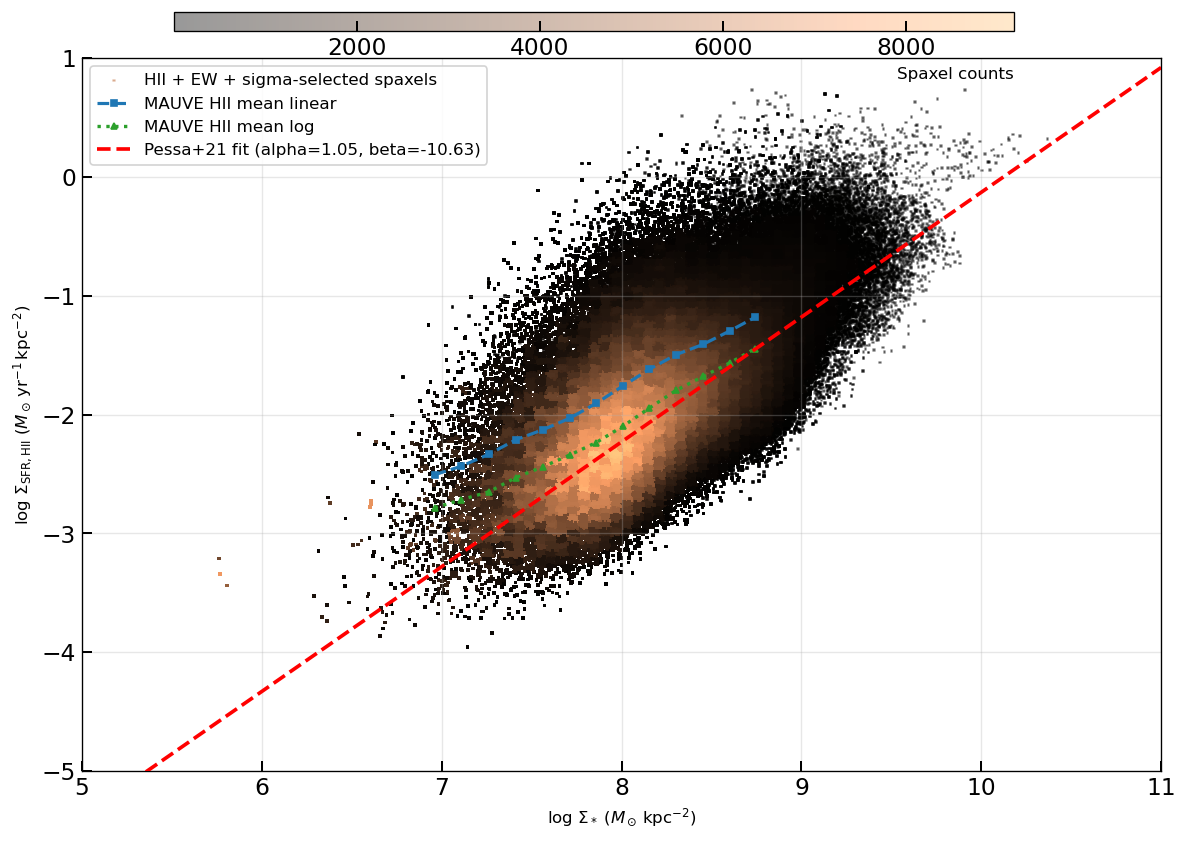

In [4]:
# ------------------------------------------------------------------
# COMBINED PLOT - rSFMS with consistent HII + EW + sigma selection
# Current full further sample, independent of infall stage
# ------------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits

EW_HDU = "PROXY_EWHA"
EW_MIN = 6.0
HALPHA_SIGMA_MAX = 45.0


def load_selected_rsfms_maps(galaxy):
    """Load and align the four maps needed by the shared rSFMS selection."""
    spatial_path = further_spatial_path(galaxy)
    gas_path = further_gas_path(galaxy)
    ew_path = further_ew_path(galaxy)

    with fits.open(spatial_path) as hdul:
        log_sigma_m = np.asarray(
            hdul["LOGMASS_SURFACE_DENSITY"].data, dtype=float
        )
    with fits.open(gas_path) as hdul:
        log_sigma_sfr = np.asarray(
            hdul["LOGSFR_SURFACE_DENSITY_HII"].data, dtype=float
        )
        halpha_sigma_obs = np.asarray(hdul["HA6562_SIGMA"].data, dtype=float)
        halpha_sigma_corr = np.asarray(
            hdul["HA6562_SIGMA_CORR"].data, dtype=float
        )
    with fits.open(ew_path) as hdul:
        ew_ha = np.asarray(hdul[EW_HDU].data, dtype=float)

    target_shape = log_sigma_sfr.shape
    log_sigma_m = align_map_to_shape(
        log_sigma_m, target_shape, label=f"{galaxy} stellar mass"
    )
    ew_ha = align_map_to_shape(
        ew_ha, target_shape, label=f"{galaxy} {EW_HDU}"
    )
    halpha_sigma_obs = align_map_to_shape(
        halpha_sigma_obs, target_shape, label=f"{galaxy} HA6562_SIGMA"
    )
    halpha_sigma_corr = align_map_to_shape(
        halpha_sigma_corr, target_shape, label=f"{galaxy} HA6562_SIGMA_CORR"
    )

    sigma2_intrinsic = halpha_sigma_obs**2 - halpha_sigma_corr**2
    halpha_sigma = np.full(target_shape, np.nan, dtype=float)
    sigma_ok = np.isfinite(sigma2_intrinsic) & (sigma2_intrinsic > 0)
    halpha_sigma[sigma_ok] = np.sqrt(sigma2_intrinsic[sigma_ok])
    return log_sigma_m, log_sigma_sfr, ew_ha, halpha_sigma


def selected_rsfms_mask(log_sigma_m, log_sigma_sfr, ew_ha, halpha_sigma):
    """Select HII spaxels with EW(Halpha)>6 A and intrinsic sigma<45 km/s."""
    return (
        np.isfinite(log_sigma_m)
        & np.isfinite(log_sigma_sfr)
        & np.isfinite(ew_ha)
        & (ew_ha > EW_MIN)
        & np.isfinite(halpha_sigma)
        & (halpha_sigma < HALPHA_SIGMA_MAX)
    )


def binned_rsfms_mean_trends(x, y, *, bin_width, min_pixels):
    """Bin the central 95% in mass and preserve gaps between valid bins."""
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    finite = np.isfinite(x) & np.isfinite(y)
    x = x[finite]
    y = y[finite]
    trend_lo, trend_hi = np.nanpercentile(x, [2.5, 97.5])
    central = (x >= trend_lo) & (x <= trend_hi)
    x_data = x[central]
    y_data = y[central]

    edges = np.arange(trend_lo, trend_hi, bin_width)
    if edges.size == 0:
        edges = np.asarray([trend_lo])
    if edges[-1] < trend_hi:
        edges = np.append(edges, trend_hi)

    trend_x = []
    mean_linear = []
    mean_log = []
    counts = []
    last_bin = len(edges) - 2
    for index, (left, right) in enumerate(zip(edges[:-1], edges[1:])):
        if index == last_bin:
            in_bin = (x_data >= left) & (x_data <= right)
        else:
            in_bin = (x_data >= left) & (x_data < right)
        count = int(np.count_nonzero(in_bin))
        counts.append(count)
        if count < min_pixels:
            trend_x.append(0.5 * (left + right))
            mean_linear.append(np.nan)
            mean_log.append(np.nan)
            continue

        x_bin = x_data[in_bin]
        y_bin = y_data[in_bin]
        trend_x.append(np.mean(x_bin))
        mean_linear.append(np.log10(np.mean(10 ** y_bin)))
        mean_log.append(np.mean(y_bin))

    return (
        np.asarray(trend_x),
        np.asarray(mean_linear),
        np.asarray(mean_log),
        np.asarray(counts, dtype=int),
        (trend_lo, trend_hi),
    )


# Discover every current further galaxy with mass, HII-SFR, and EW maps.
full_sample_galaxies = PRODUCTS.index[
    PRODUCTS["has_mass_map"]
    & PRODUCTS["has_sfr_map"]
    & PRODUCTS["has_proxy_ew"]
].tolist()

all_x_full = []
all_y_full = []
full_sample_galaxy_counts = {}

for galaxy in full_sample_galaxies:
    maps = load_selected_rsfms_maps(galaxy)
    selected = selected_rsfms_mask(*maps)
    log_sigma_m, log_sigma_sfr, _, _ = maps

    if np.any(selected):
        x_det = log_sigma_m[selected]
        y_det = log_sigma_sfr[selected]
        all_x_full.extend(x_det.ravel())
        all_y_full.extend(y_det.ravel())
        full_sample_galaxy_counts[galaxy] = int(x_det.size)
    else:
        full_sample_galaxy_counts[galaxy] = 0
        print(f"Skipping {galaxy}: no HII+EW+sigma-selected spaxels")

all_x_full = np.asarray(all_x_full, dtype=float)
all_y_full = np.asarray(all_y_full, dtype=float)
if all_x_full.size == 0:
    raise RuntimeError("No valid HII+EW+sigma rSFMS data found.")

print(
    "Selected full-sample HII spaxels "
    f"(EW(Ha)>{EW_MIN:g} A, intrinsic sigma<{HALPHA_SIGMA_MAX:g} km/s): "
    f"{all_y_full.size:,}"
)

fig, ax_combined = plt.subplots(figsize=(10, 8))

# Density-colored scatter of all selected pixels.
H, xedges, yedges = np.histogram2d(
    all_x_full,
    all_y_full,
    bins=100,
    range=[[5, 11], [-5, 1]],
)
x_idx = np.clip(np.digitize(all_x_full, xedges) - 1, 0, H.shape[0] - 1)
y_idx = np.clip(np.digitize(all_y_full, yedges) - 1, 0, H.shape[1] - 1)
density = H[x_idx, y_idx]

scatter = ax_combined.scatter(
    all_x_full,
    all_y_full,
    c=density,
    s=1,
    alpha=0.4,
    marker=",",
    cmap="copper",
    label="HII + EW + sigma-selected spaxels",
    zorder=1,
)

# Mean trends use exact percentile bounds. NaNs preserve gaps where a bin
# contains fewer than 50 selected pixels, preventing unsupported line segments.
(
    trend_x_full,
    mean_linear_hii_full,
    mean_log_hii_full,
    trend_counts_full,
    (trend_lo_full, trend_hi_full),
) = binned_rsfms_mean_trends(
    all_x_full,
    all_y_full,
    bin_width=0.15,
    min_pixels=50,
)
bin_width = 0.15
min_pixels_per_bin = 50

ax_combined.plot(
    trend_x_full,
    mean_linear_hii_full,
    color="tab:blue",
    linestyle="--",
    marker="s",
    markersize=3.2,
    linewidth=1.9,
    label="MAUVE HII mean linear",
    zorder=7,
)
ax_combined.plot(
    trend_x_full,
    mean_log_hii_full,
    color="tab:green",
    linestyle=":",
    marker="^",
    markersize=3.6,
    linewidth=2.0,
    label="MAUVE HII mean log",
    zorder=7,
)

pessa_alpha_full = 1.05
pessa_intercept_full = -10.63
x_pessa_full = np.linspace(5, 11, 200)
y_pessa_full = pessa_alpha_full * x_pessa_full + pessa_intercept_full
ax_combined.plot(
    x_pessa_full,
    y_pessa_full,
    color="red",
    linestyle="--",
    linewidth=2.2,
    label="Pessa+21 fit (alpha=1.05, beta=-10.63)",
    zorder=8,
)

ax_combined.set_xlabel(r"$\log\,\Sigma_* \; (M_\odot\,\mathrm{kpc}^{-2})$")
ax_combined.set_ylabel(
    r"$\log\,\Sigma_{\mathrm{SFR,HII}}\; "
    r"(M_\odot\,\mathrm{yr}^{-1}\,\mathrm{kpc}^{-2})$"
)
ax_combined.set_xlim(5, 11)
ax_combined.set_ylim(-5, 1)
ax_combined.grid(True, alpha=0.3)
ax_combined.legend(
    loc="upper left", ncol=1, frameon=True, framealpha=0.85
)

cbar_ax = fig.add_axes([0.15, 0.85, 0.7, 0.02])
cbar = plt.colorbar(scatter, cax=cbar_ax, orientation="horizontal")
cbar.set_label("Spaxel counts", loc="right")
plt.tight_layout(rect=[0, 0, 1, 0.85])
# plt.savefig(OUTDIR / "rSFMS_combined_full_further.png", dpi=600, bbox_inches="tight")
# plt.savefig(OUTDIR / "rSFMS_combined_full_further.pdf", bbox_inches="tight")
plt.show()


## Pre-peak resolved star-forming main sequence

Pale cyan-blue points are the pooled pre-peak HII-region spaxels. The two summary
curves follow the detected-pixel definitions in cell 25 of
`20260412_Plot_Paper_1_referee.ipynb`: log10 of the mean linear Σ_SFR and the
mean log Σ_SFR in 0.15 dex stellar-mass bins. The red dashed curve is the
published Pessa et al. (2021) 100 pc fit.


  NGC4189: 96,364 pre-peak selected HII spaxels
  NGC4192: 144,333 pre-peak selected HII spaxels
  NGC4254: 661,963 pre-peak selected HII spaxels
  NGC4294: 68,833 pre-peak selected HII spaxels
  NGC4321: 454,131 pre-peak selected HII spaxels
  NGC4351: 30,711 pre-peak selected HII spaxels
  NGC4383: 25,212 pre-peak selected HII spaxels
  NGC4396: 85,378 pre-peak selected HII spaxels
  NGC4535: 187,113 pre-peak selected HII spaxels
  NGC4567_8: 222,533 pre-peak selected HII spaxels


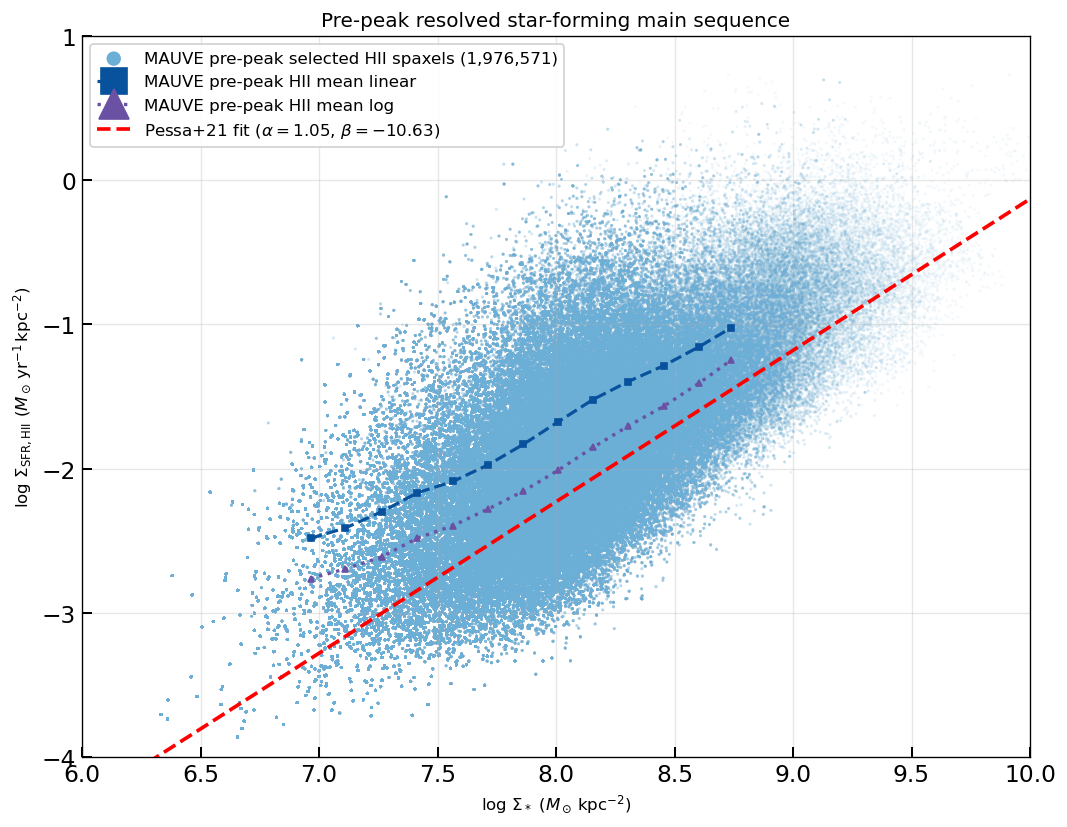


Pre-peak rSFMS sample:
  Spaxels: 1,976,571
  Galaxies: NGC4189, NGC4192, NGC4254, NGC4294, NGC4321, NGC4351, NGC4383, NGC4396, NGC4535, NGC4567_8
  EW(Ha) cut: > 6 A
  Intrinsic Halpha dispersion cut: < 45 km/s
  Trend mass range (central 95%): 6.886 to 8.797


In [5]:
# Pre-peak rSFMS with the shared HII + EW + intrinsic-sigma selection.
RSFMS_XRANGE = (6.0, 10.0)
RSFMS_YRANGE = (-4.0, 1.0)
RSFMS_BIN_WIDTH = 0.15
RSFMS_MIN_PIXELS_PER_BIN = 50
RSFMS_STAGE = 1
RSFMS_SCATTER_COLOR = "#6BAED6"
RSFMS_MEAN_LINEAR_COLOR = "#08519C"
RSFMS_MEAN_LOG_COLOR = "#6A51A3"


with fits.open(PROJECT_ROOT / "mauve_master_wiki_newclass.fits") as hdul:
    rsfms_infall_class = {
        row["Galaxy"].strip(): int(row["class"])
        for row in hdul[1].data
    }
rsfms_infall_class = add_combined_infall_classes(rsfms_infall_class)

rsfms_ready = (
    PRODUCTS["has_mass_map"]
    & PRODUCTS["has_sfr_map"]
    & PRODUCTS["has_proxy_ew"]
)
rsfms_galaxies = PRODUCTS.index[rsfms_ready].tolist()
all_log_sigma_m = []
all_log_sigma_sfr = []
included_rsfms_galaxies = []

print("Collecting pre-peak HII+EW+sigma-selected spaxels...")
for galaxy in rsfms_galaxies:
    stage = rsfms_infall_class.get(galaxy)
    if stage != RSFMS_STAGE:
        continue

    try:
        maps = load_selected_rsfms_maps(galaxy)
        selected = selected_rsfms_mask(*maps)
        log_sigma_m, log_sigma_sfr, _, _ = maps
    except Exception as exc:
        print(f"  {galaxy}: skipped - {exc}")
        continue

    n_spaxels = int(selected.sum())
    print(f"  {galaxy}: {n_spaxels:,} pre-peak selected HII spaxels")
    if n_spaxels == 0:
        continue
    included_rsfms_galaxies.append(galaxy)
    all_log_sigma_m.extend(log_sigma_m[selected].ravel())
    all_log_sigma_sfr.extend(log_sigma_sfr[selected].ravel())

all_log_sigma_m = np.asarray(all_log_sigma_m, dtype=float)
all_log_sigma_sfr = np.asarray(all_log_sigma_sfr, dtype=float)
if all_log_sigma_m.size == 0:
    raise RuntimeError("No valid pre-peak HII+EW+sigma-selected spaxels found.")

# Both means use exact central-95% bounds; under-populated bins remain
# as NaN gaps so the plotted curves never bridge unsupported mass intervals.
(
    trend_x,
    mean_linear_hii,
    mean_log_hii,
    trend_counts,
    (trend_lo, trend_hi),
) = binned_rsfms_mean_trends(
    all_log_sigma_m,
    all_log_sigma_sfr,
    bin_width=RSFMS_BIN_WIDTH,
    min_pixels=RSFMS_MIN_PIXELS_PER_BIN,
)

fig, ax = plt.subplots(figsize=(9, 7))
ax.scatter(
    all_log_sigma_m,
    all_log_sigma_sfr,
    s=3,
    alpha=0.08,
    color=RSFMS_SCATTER_COLOR,
    edgecolors="none",
    rasterized=True,
    label=f"MAUVE pre-peak selected HII spaxels ({all_log_sigma_m.size:,})",
    zorder=1,
)
ax.plot(
    trend_x,
    mean_linear_hii,
    color=RSFMS_MEAN_LINEAR_COLOR,
    linestyle="--",
    marker="s",
    markersize=3.2,
    linewidth=1.9,
    label="MAUVE pre-peak HII mean linear",
    zorder=7,
)
ax.plot(
    trend_x,
    mean_log_hii,
    color=RSFMS_MEAN_LOG_COLOR,
    linestyle=":",
    marker="^",
    markersize=3.6,
    linewidth=2.0,
    label="MAUVE pre-peak HII mean log",
    zorder=7,
)

pessa_alpha = 1.05
pessa_intercept = -10.63
x_pessa = np.linspace(*RSFMS_XRANGE, 200)
y_pessa = pessa_alpha * x_pessa + pessa_intercept
ax.plot(
    x_pessa,
    y_pessa,
    color="red",
    linestyle="--",
    linewidth=2.2,
    label=r"Pessa+21 fit ($\alpha=1.05$, $\beta=-10.63$)",
    zorder=8,
)

ax.set(
    xlabel=r"$\log\,\Sigma_* \ (M_\odot\,\mathrm{kpc}^{-2})$",
    ylabel=(
        r"$\log\,\Sigma_{\mathrm{SFR,HII}} \ "
        r"(M_\odot\,\mathrm{yr}^{-1}\,\mathrm{kpc}^{-2})$"
    ),
    xlim=RSFMS_XRANGE,
    ylim=RSFMS_YRANGE,
    title="Pre-peak resolved star-forming main sequence",
)
ax.grid(True, alpha=0.3)
legend = ax.legend(loc="upper left", framealpha=0.9, markerscale=5)
for handle in legend.legend_handles:
    if hasattr(handle, "set_alpha"):
        handle.set_alpha(1.0)
plt.tight_layout()
# plt.savefig(OUTDIR / "MAUVE_MUSE_rSFMS_pre_peak_EW_sigma.png", dpi=600, bbox_inches="tight")
# plt.savefig(OUTDIR / "MAUVE_MUSE_rSFMS_pre_peak_EW_sigma.pdf", bbox_inches="tight")
plt.show()

print("\nPre-peak rSFMS sample:")
print(f"  Spaxels: {all_log_sigma_m.size:,}")
print(f"  Galaxies: {', '.join(included_rsfms_galaxies)}")
print(f"  EW(Ha) cut: > {EW_MIN:g} A")
print(f"  Intrinsic Halpha dispersion cut: < {HALPHA_SIGMA_MAX:g} km/s")
print(f"  Trend mass range (central 95%): {trend_lo:.3f} to {trend_hi:.3f}")


  IC3392: 13,897 Post-peak selected spaxels
  NGC4064: 3,273 Post-peak selected spaxels
  NGC4293: 471 Post-peak selected spaxels
  NGC4298: 144,157 Close-to-peak selected spaxels
  NGC4302: 27,304 Close-to-peak selected spaxels
  NGC4330: 35,688 Close-to-peak selected spaxels
  NGC4380: 64,097 Post-peak selected spaxels
  NGC4388: 17,663 Close-to-peak selected spaxels
  NGC4394: 31,915 Post-peak selected spaxels
  NGC4402: 46,769 Close-to-peak selected spaxels
  NGC4405: 13,569 Post-peak selected spaxels
  NGC4419: 5,763 Post-peak selected spaxels
  NGC4450: 17,186 Post-peak selected spaxels
  NGC4457: 5,604 Post-peak selected spaxels
  NGC4501: 251,936 Close-to-peak selected spaxels
  NGC4522: 48,946 Close-to-peak selected spaxels
  NGC4569: 45,477 Post-peak selected spaxels
  NGC4580: 22,438 Post-peak selected spaxels
  NGC4606: 1,752 Post-peak selected spaxels
  NGC4607: 17,988 Post-peak selected spaxels
  NGC4694: 1,058 Close-to-peak selected spaxels
  NGC4698: 6,744 Post-peak sel

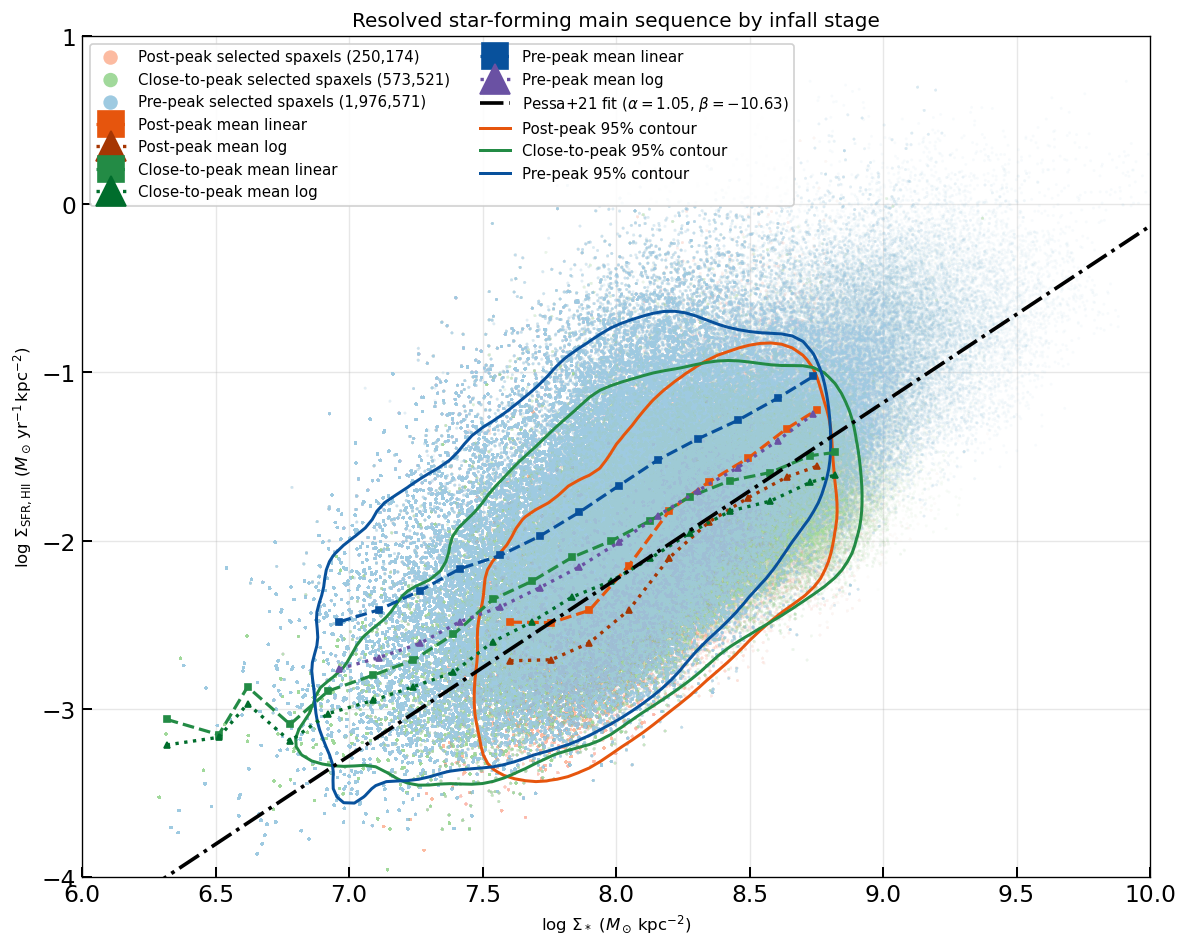


rSFMS sample by infall stage:
  Pre-peak: 1,976,571 spaxels from 10 galaxies
  Close-to-peak: 573,521 spaxels from 8 galaxies
  Post-peak: 250,174 spaxels from 14 galaxies
Selection: HII + EW(Ha)>6 A + intrinsic sigma<45 km/s
Trends: central 95% in stellar mass, 0.15-dex bins, >=50 pixels per bin


In [6]:
# Add close-to-peak and post-peak samples using the same selection.
from matplotlib.lines import Line2D
from scipy.ndimage import gaussian_filter

RSFMS_STAGE_LABELS = {
    1: "Pre-peak",
    2: "Close-to-peak",
    3: "Post-peak",
}
RSFMS_STAGE_STYLE = {
    1: {
        "scatter": "#9ECAE1",
        "mean_linear": "#08519C",
        "mean_log": "#6A51A3",
        "alpha": 0.08,
        "zorder": 3.0,
    },
    2: {
        "scatter": "#A1D99B",
        "mean_linear": "#238B45",
        "mean_log": "#006D2C",
        "alpha": 0.035,
        "zorder": 2.0,
    },
    3: {
        "scatter": "#FCBBA1",
        "mean_linear": "#E6550D",
        "mean_log": "#A63603",
        "alpha": 0.025,
        "zorder": 1.0,
    },
}
STAGE_CONTOUR_ZORDER = 4.0
STAGE_TREND_ZORDER = 6.0
RSFMS_CONTOUR_BINS = 100
RSFMS_CONTOUR_SMOOTHING = 2.0

stage_log_sigma_m = {
    1: np.asarray(all_log_sigma_m, dtype=float),
    2: [],
    3: [],
}
stage_log_sigma_sfr = {
    1: np.asarray(all_log_sigma_sfr, dtype=float),
    2: [],
    3: [],
}
stage_galaxies = {
    1: list(included_rsfms_galaxies),
    2: [],
    3: [],
}

print("Collecting close-to-peak and post-peak selected HII spaxels...")
for galaxy in rsfms_galaxies:
    stage = rsfms_infall_class.get(galaxy)
    if stage not in (2, 3):
        continue

    try:
        maps = load_selected_rsfms_maps(galaxy)
        selected = selected_rsfms_mask(*maps)
        log_sigma_m, log_sigma_sfr, _, _ = maps
    except Exception as exc:
        print(f"  {galaxy}: skipped - {exc}")
        continue

    n_spaxels = int(selected.sum())
    print(f"  {galaxy}: {n_spaxels:,} {RSFMS_STAGE_LABELS[stage]} selected spaxels")
    if n_spaxels == 0:
        continue
    stage_galaxies[stage].append(galaxy)
    stage_log_sigma_m[stage].extend(log_sigma_m[selected].ravel())
    stage_log_sigma_sfr[stage].extend(log_sigma_sfr[selected].ravel())

for stage in (2, 3):
    stage_log_sigma_m[stage] = np.asarray(stage_log_sigma_m[stage], dtype=float)
    stage_log_sigma_sfr[stage] = np.asarray(stage_log_sigma_sfr[stage], dtype=float)


def plot_stage_95_contour(ax, x, y, *, color, zorder):
    """Plot one 95%-population contour for a stage's central-95% mass sample."""
    trend_lo, trend_hi = np.nanpercentile(x, [2.5, 97.5])
    central = (x >= trend_lo) & (x <= trend_hi)
    histogram, xedges, yedges = np.histogram2d(
        x[central],
        y[central],
        bins=RSFMS_CONTOUR_BINS,
        range=[RSFMS_XRANGE, RSFMS_YRANGE],
    )
    smoothed = gaussian_filter(histogram, sigma=RSFMS_CONTOUR_SMOOTHING)
    ranked = np.sort(smoothed[smoothed > 0].ravel())[::-1]
    if ranked.size == 0:
        return None
    cumulative = np.cumsum(ranked)
    level_index = np.searchsorted(cumulative, 0.95 * cumulative[-1])
    level_95 = ranked[min(level_index, ranked.size - 1)]
    xcenters = 0.5 * (xedges[:-1] + xedges[1:])
    ycenters = 0.5 * (yedges[:-1] + yedges[1:])
    return ax.contour(
        xcenters,
        ycenters,
        smoothed.T,
        levels=[level_95],
        colors=[color],
        linewidths=1.8,
        linestyles="-",
        zorder=zorder,
    )


fig, ax = plt.subplots(figsize=(10, 8))

# Scatter: post-peak lowest, close-to-peak next, pre-peak highest.
for stage in (3, 2, 1):
    x = stage_log_sigma_m[stage]
    y = stage_log_sigma_sfr[stage]
    if x.size == 0:
        continue
    style = RSFMS_STAGE_STYLE[stage]
    ax.scatter(
        x,
        y,
        s=3,
        alpha=style["alpha"],
        color=style["scatter"],
        edgecolors="none",
        rasterized=True,
        zorder=style["zorder"],
        label=f"{RSFMS_STAGE_LABELS[stage]} selected spaxels ({x.size:,})",
    )

# One 95%-population contour per stage, above scatter and below all means.
contour_handles = []
for stage in (3, 2, 1):
    x = stage_log_sigma_m[stage]
    y = stage_log_sigma_sfr[stage]
    if x.size == 0:
        continue
    style = RSFMS_STAGE_STYLE[stage]
    plot_stage_95_contour(
        ax,
        x,
        y,
        color=style["mean_linear"],
        zorder=STAGE_CONTOUR_ZORDER + 0.1 * style["zorder"],
    )
    contour_handles.append(
        Line2D(
            [0], [0], color=style["mean_linear"], linewidth=1.8,
            label=f"{RSFMS_STAGE_LABELS[stage]} 95% contour",
        )
    )

# All mean curves are above every scatter and contour layer.
for stage in (3, 2, 1):
    x = stage_log_sigma_m[stage]
    y = stage_log_sigma_sfr[stage]
    if x.size == 0:
        continue
    style = RSFMS_STAGE_STYLE[stage]
    (
        trend_x,
        mean_linear,
        mean_log,
        trend_counts,
        trend_limits,
    ) = binned_rsfms_mean_trends(
        x,
        y,
        bin_width=RSFMS_BIN_WIDTH,
        min_pixels=RSFMS_MIN_PIXELS_PER_BIN,
    )
    ax.plot(
        trend_x,
        mean_linear,
        color=style["mean_linear"],
        linestyle="--",
        marker="s",
        markersize=3.2,
        linewidth=1.9,
        zorder=STAGE_TREND_ZORDER + style["zorder"],
        label=f"{RSFMS_STAGE_LABELS[stage]} mean linear",
    )
    ax.plot(
        trend_x,
        mean_log,
        color=style["mean_log"],
        linestyle=":",
        marker="^",
        markersize=3.6,
        linewidth=2.0,
        zorder=STAGE_TREND_ZORDER + style["zorder"] + 0.1,
        label=f"{RSFMS_STAGE_LABELS[stage]} mean log",
    )

x_pessa = np.linspace(*RSFMS_XRANGE, 200)
y_pessa = pessa_alpha * x_pessa + pessa_intercept
ax.plot(
    x_pessa,
    y_pessa,
    color="black",
    linestyle="-.",
    linewidth=2.2,
    zorder=10.0,
    label=r"Pessa+21 fit ($\alpha=1.05$, $\beta=-10.63$)",
)

ax.set(
    xlabel=r"$\log\,\Sigma_* \ (M_\odot\,\mathrm{kpc}^{-2})$",
    ylabel=(
        r"$\log\,\Sigma_{\mathrm{SFR,HII}} \ "
        r"(M_\odot\,\mathrm{yr}^{-1}\,\mathrm{kpc}^{-2})$"
    ),
    xlim=RSFMS_XRANGE,
    ylim=RSFMS_YRANGE,
    title="Resolved star-forming main sequence by infall stage",
)
ax.grid(True, alpha=0.3)
handles, labels = ax.get_legend_handles_labels()
handles.extend(contour_handles)
labels.extend(handle.get_label() for handle in contour_handles)
legend = ax.legend(
    handles=handles,
    labels=labels,
    loc="upper left",
    ncol=2,
    fontsize=9,
    framealpha=0.9,
    markerscale=5,
)
for handle in legend.legend_handles:
    if hasattr(handle, "set_alpha"):
        handle.set_alpha(1.0)
plt.tight_layout()
# plt.savefig(OUTDIR / "MAUVE_MUSE_rSFMS_all_infall_stages_EW_sigma.png", dpi=600, bbox_inches="tight")
# plt.savefig(OUTDIR / "MAUVE_MUSE_rSFMS_all_infall_stages_EW_sigma.pdf", bbox_inches="tight")
plt.show()

print("\nrSFMS sample by infall stage:")
for stage in (1, 2, 3):
    print(
        f"  {RSFMS_STAGE_LABELS[stage]}: "
        f"{stage_log_sigma_m[stage].size:,} spaxels from "
        f"{len(stage_galaxies[stage])} galaxies"
    )
print(f"Selection: HII + EW(Ha)>{EW_MIN:g} A + intrinsic sigma<{HALPHA_SIGMA_MAX:g} km/s")
print(
    f"Trends: central 95% in stellar mass, {RSFMS_BIN_WIDTH:g}-dex bins, "
    f">={RSFMS_MIN_PIXELS_PER_BIN} pixels per bin"
)


## Individual pre-peak galaxy rSFMS checks

The pooled pre-peak relation may suggest an SFR enhancement, but that
signal could be driven by only one or two systems. The following cells therefore
inspect every currently available pre-peak galaxy individually, using the same
HII + EW(Hα) > 6 Å + intrinsic Hα dispersion < 45 km s⁻¹ selection, central-95%
stellar-mass range, 0.15-dex bins, ≥50-pixel requirement, 95%-population contour,
and Pessa et al. (2021) reference as the combined comparison.

`NGC4567_8` is treated as one combined system here.


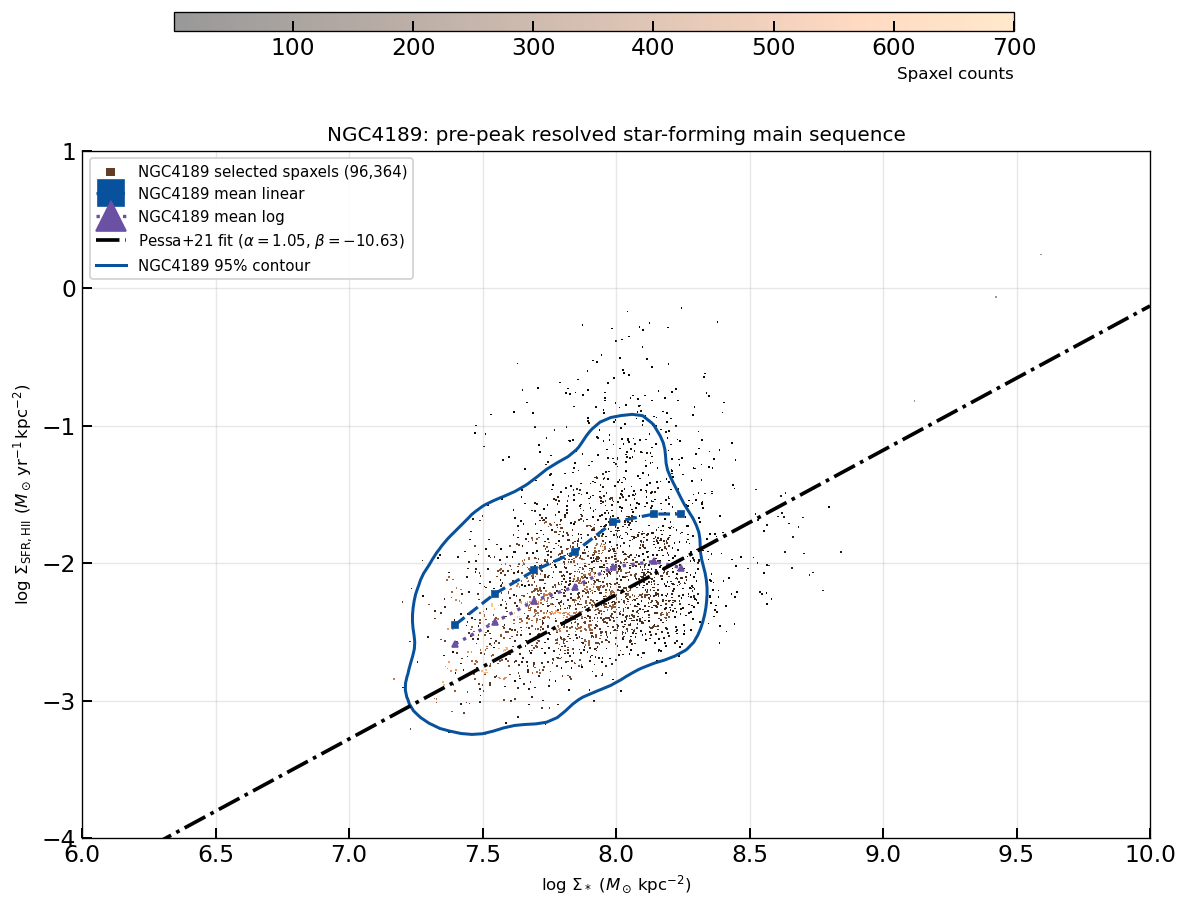

NGC4189: 96,364 selected spaxels
  Central-95% stellar-mass range: 7.320 to 8.273
  Valid trend bins: 7 of 7


In [7]:
def plot_individual_prepeak_rsfms(galaxy):
    """Plot the selected rSFMS, two means, and 95% contour for one galaxy."""
    if galaxy not in rsfms_galaxies:
        raise ValueError(f"{galaxy} is not available for the rSFMS analysis")
    if rsfms_infall_class.get(galaxy) != RSFMS_STAGE:
        raise ValueError(f"{galaxy} is not a pre-peak galaxy")

    maps = load_selected_rsfms_maps(galaxy)
    selected = selected_rsfms_mask(*maps)
    log_sigma_m, log_sigma_sfr, _, _ = maps
    x = np.asarray(log_sigma_m[selected], dtype=float)
    y = np.asarray(log_sigma_sfr[selected], dtype=float)
    if x.size == 0:
        raise RuntimeError(f"{galaxy}: no HII+EW+sigma-selected spaxels")

    (
        trend_x,
        mean_linear,
        mean_log,
        trend_counts,
        (trend_lo, trend_hi),
    ) = binned_rsfms_mean_trends(
        x,
        y,
        bin_width=RSFMS_BIN_WIDTH,
        min_pixels=RSFMS_MIN_PIXELS_PER_BIN,
    )

    fig, ax = plt.subplots(figsize=(10, 8))

    # Match cell 6: density-coloured scatter for this galaxy only.
    histogram, xedges, yedges = np.histogram2d(
        x,
        y,
        bins=100,
        range=[RSFMS_XRANGE, RSFMS_YRANGE],
    )
    x_index = np.clip(np.digitize(x, xedges) - 1, 0, histogram.shape[0] - 1)
    y_index = np.clip(np.digitize(y, yedges) - 1, 0, histogram.shape[1] - 1)
    density = histogram[x_index, y_index]
    scatter = ax.scatter(
        x,
        y,
        c=density,
        s=1,
        alpha=0.4,
        marker=",",
        cmap="copper",
        edgecolors="none",
        rasterized=True,
        zorder=1,
        label=f"{galaxy} selected spaxels ({x.size:,})",
    )

    # Keep cell 9's single 95%-population contour below both mean curves.
    plot_stage_95_contour(
        ax,
        x,
        y,
        color=RSFMS_MEAN_LINEAR_COLOR,
        zorder=STAGE_CONTOUR_ZORDER,
    )
    contour_handle = Line2D(
        [0],
        [0],
        color=RSFMS_MEAN_LINEAR_COLOR,
        linewidth=1.8,
        label=f"{galaxy} 95% contour",
    )

    ax.plot(
        trend_x,
        mean_linear,
        color=RSFMS_MEAN_LINEAR_COLOR,
        linestyle="--",
        marker="s",
        markersize=3.2,
        linewidth=1.9,
        zorder=7.0,
        label=f"{galaxy} mean linear",
    )
    ax.plot(
        trend_x,
        mean_log,
        color=RSFMS_MEAN_LOG_COLOR,
        linestyle=":",
        marker="^",
        markersize=3.6,
        linewidth=2.0,
        zorder=7.1,
        label=f"{galaxy} mean log",
    )

    x_pessa = np.linspace(*RSFMS_XRANGE, 200)
    y_pessa = pessa_alpha * x_pessa + pessa_intercept
    ax.plot(
        x_pessa,
        y_pessa,
        color="black",
        linestyle="-.",
        linewidth=2.2,
        zorder=8.0,
        label=r"Pessa+21 fit ($\alpha=1.05$, $\beta=-10.63$)",
    )

    ax.set(
        xlabel=r"$\log\,\Sigma_* \ (M_\odot\,\mathrm{kpc}^{-2})$",
        ylabel=(
            r"$\log\,\Sigma_{\mathrm{SFR,HII}} \ "
            r"(M_\odot\,\mathrm{yr}^{-1}\,\mathrm{kpc}^{-2})$"
        ),
        xlim=RSFMS_XRANGE,
        ylim=RSFMS_YRANGE,
        title=f"{galaxy}: pre-peak resolved star-forming main sequence",
    )
    ax.grid(True, alpha=0.3)
    handles, labels = ax.get_legend_handles_labels()
    handles.append(contour_handle)
    labels.append(contour_handle.get_label())
    legend = ax.legend(
        handles=handles,
        labels=labels,
        loc="upper left",
        ncol=1,
        fontsize=9,
        framealpha=0.9,
        markerscale=5,
    )
    for handle in legend.legend_handles:
        if hasattr(handle, "set_alpha"):
            handle.set_alpha(1.0)

    plt.tight_layout(rect=[0, 0, 1, 0.84])
    colorbar_axis = fig.add_axes([0.15, 0.92, 0.7, 0.02])
    colorbar = plt.colorbar(scatter, cax=colorbar_axis, orientation="horizontal")
    colorbar.set_label("Spaxel counts", loc="right")
    # plt.savefig(OUTDIR / f"{galaxy}_rSFMS_pre_peak_EW_sigma.png", dpi=600, bbox_inches="tight")
    # plt.savefig(OUTDIR / f"{galaxy}_rSFMS_pre_peak_EW_sigma.pdf", bbox_inches="tight")
    plt.show()

    print(f"{galaxy}: {x.size:,} selected spaxels")
    print(f"  Central-95% stellar-mass range: {trend_lo:.3f} to {trend_hi:.3f}")
    print(
        f"  Valid trend bins: {np.count_nonzero(trend_counts >= RSFMS_MIN_PIXELS_PER_BIN)} "
        f"of {trend_counts.size}"
    )


plot_individual_prepeak_rsfms("NGC4189")


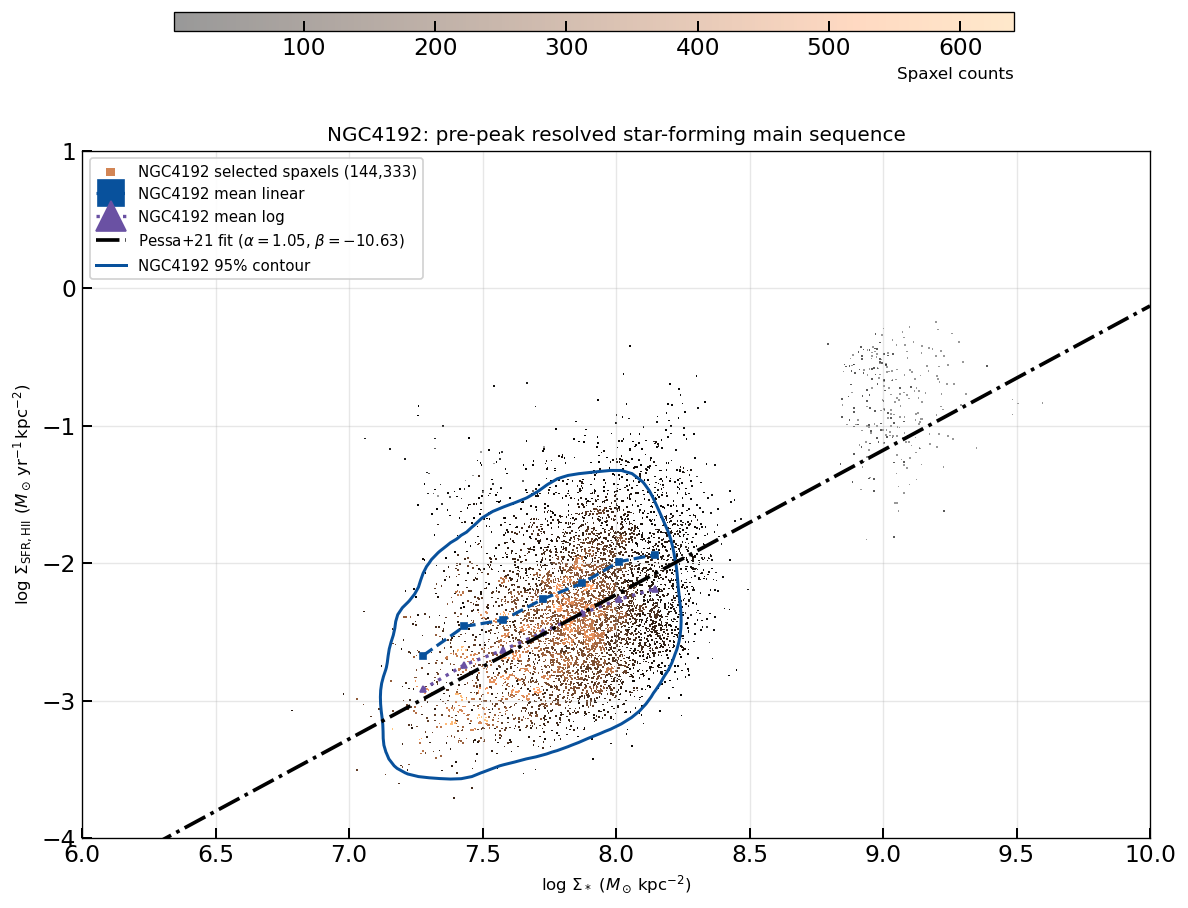

NGC4192: 144,333 selected spaxels
  Central-95% stellar-mass range: 7.200 to 8.192
  Valid trend bins: 7 of 7


In [8]:
plot_individual_prepeak_rsfms("NGC4192")


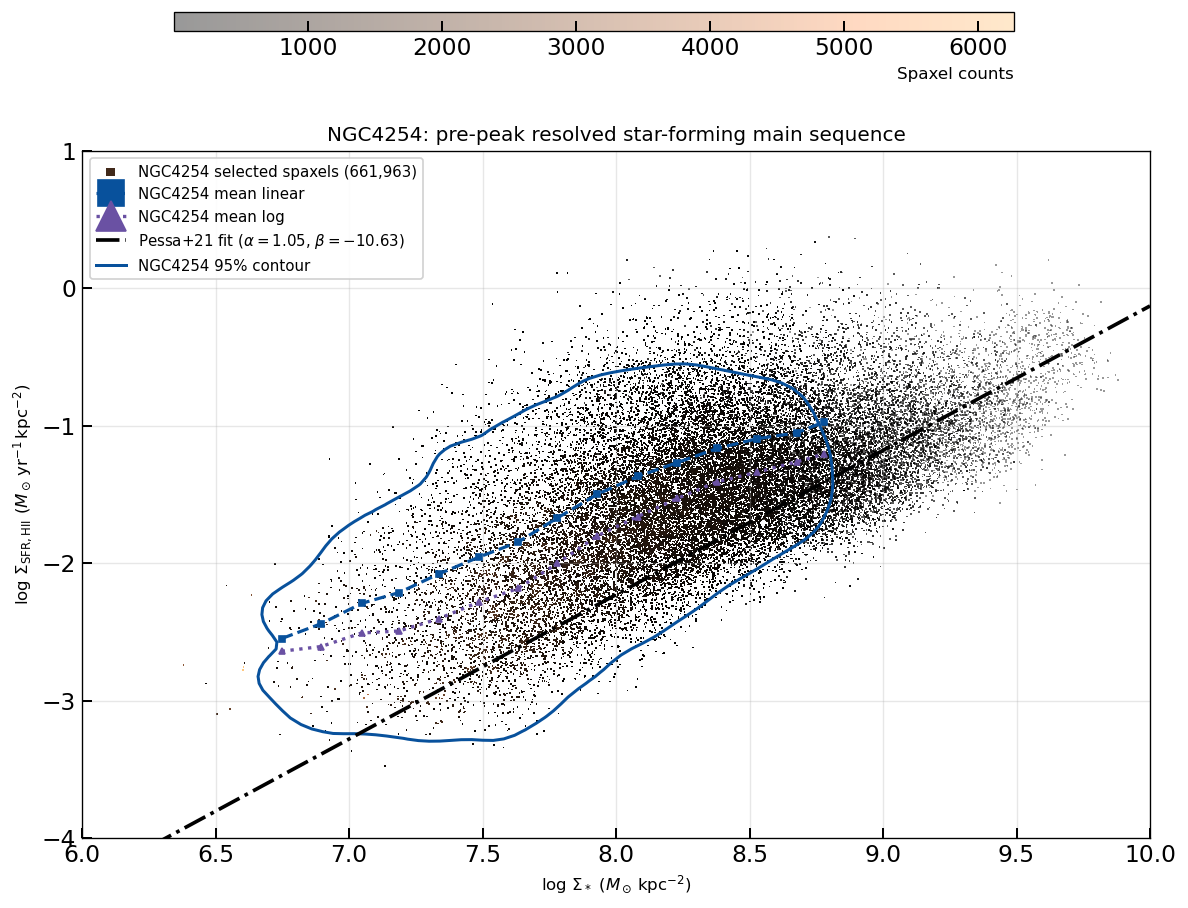

NGC4254: 661,963 selected spaxels
  Central-95% stellar-mass range: 6.657 to 8.802
  Valid trend bins: 15 of 15


In [9]:
plot_individual_prepeak_rsfms("NGC4254")


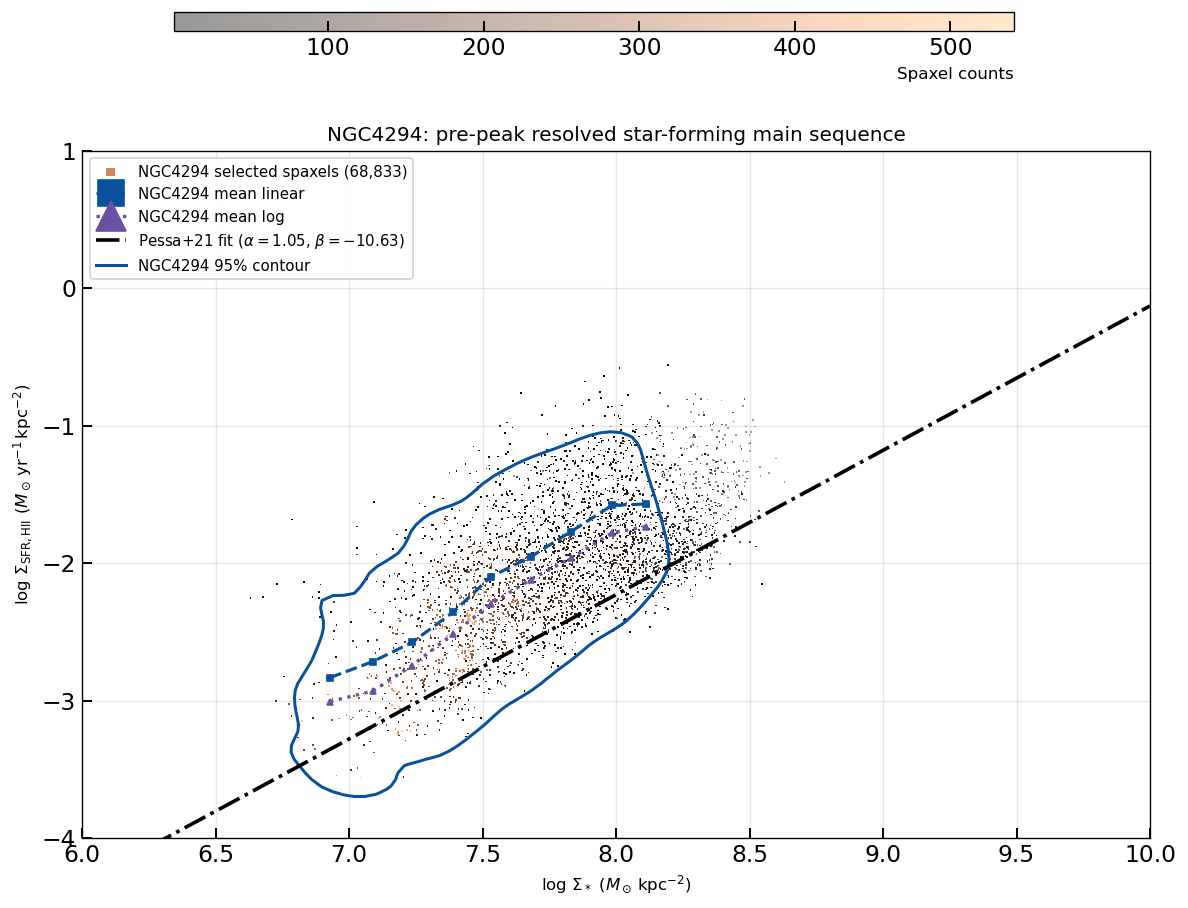

NGC4294: 68,833 selected spaxels
  Central-95% stellar-mass range: 6.863 to 8.172
  Valid trend bins: 9 of 9


In [10]:
plot_individual_prepeak_rsfms("NGC4294")


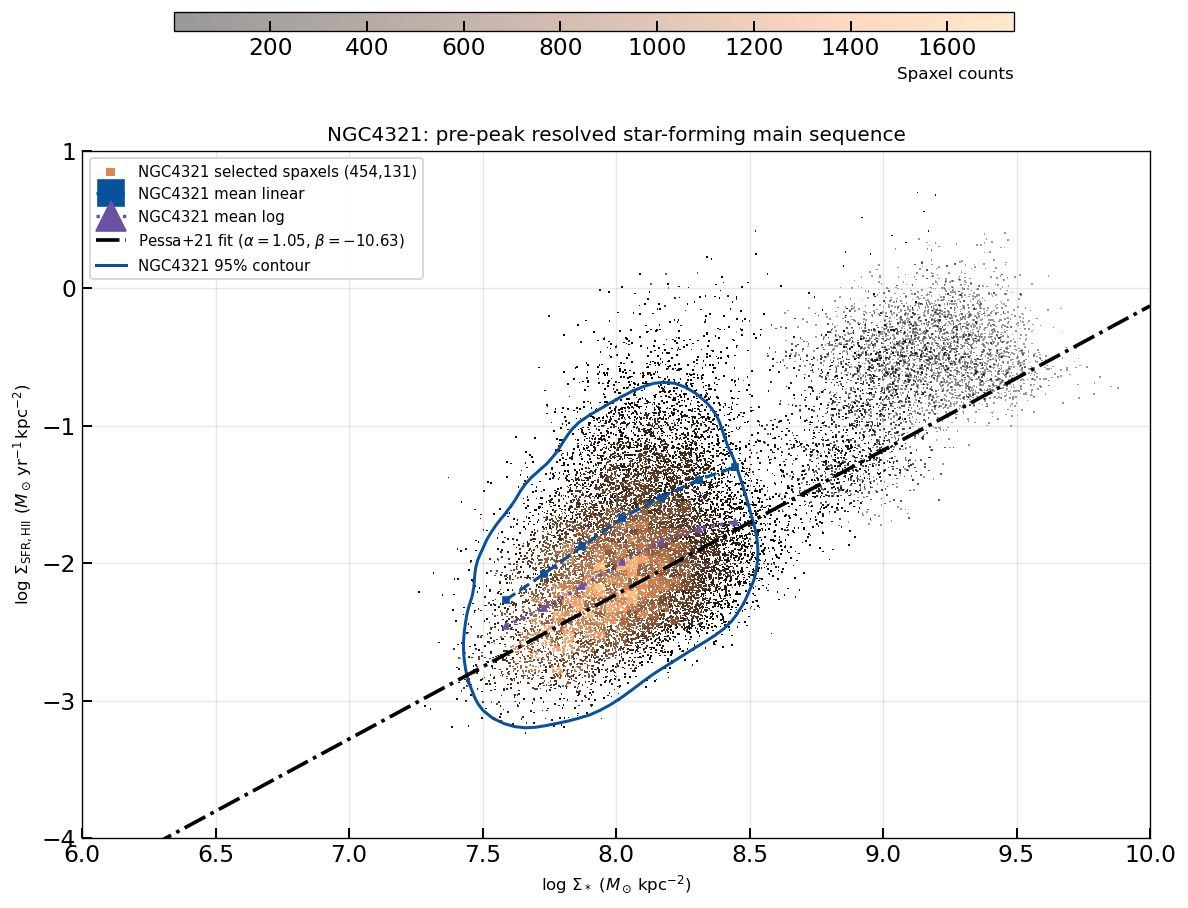

NGC4321: 454,131 selected spaxels
  Central-95% stellar-mass range: 7.499 to 8.518
  Valid trend bins: 7 of 7


In [11]:
plot_individual_prepeak_rsfms("NGC4321")


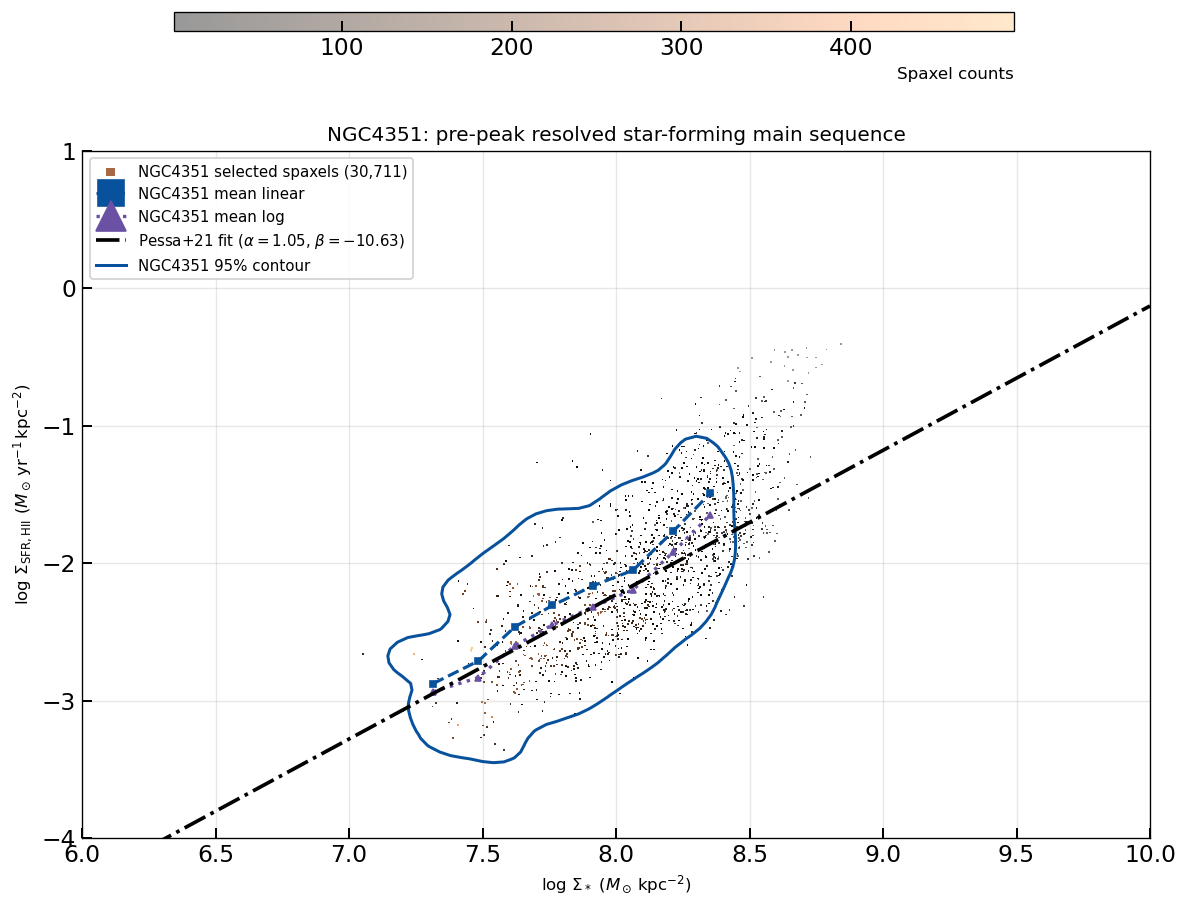

NGC4351: 30,711 selected spaxels
  Central-95% stellar-mass range: 7.243 to 8.434
  Valid trend bins: 8 of 8


In [12]:
plot_individual_prepeak_rsfms("NGC4351")


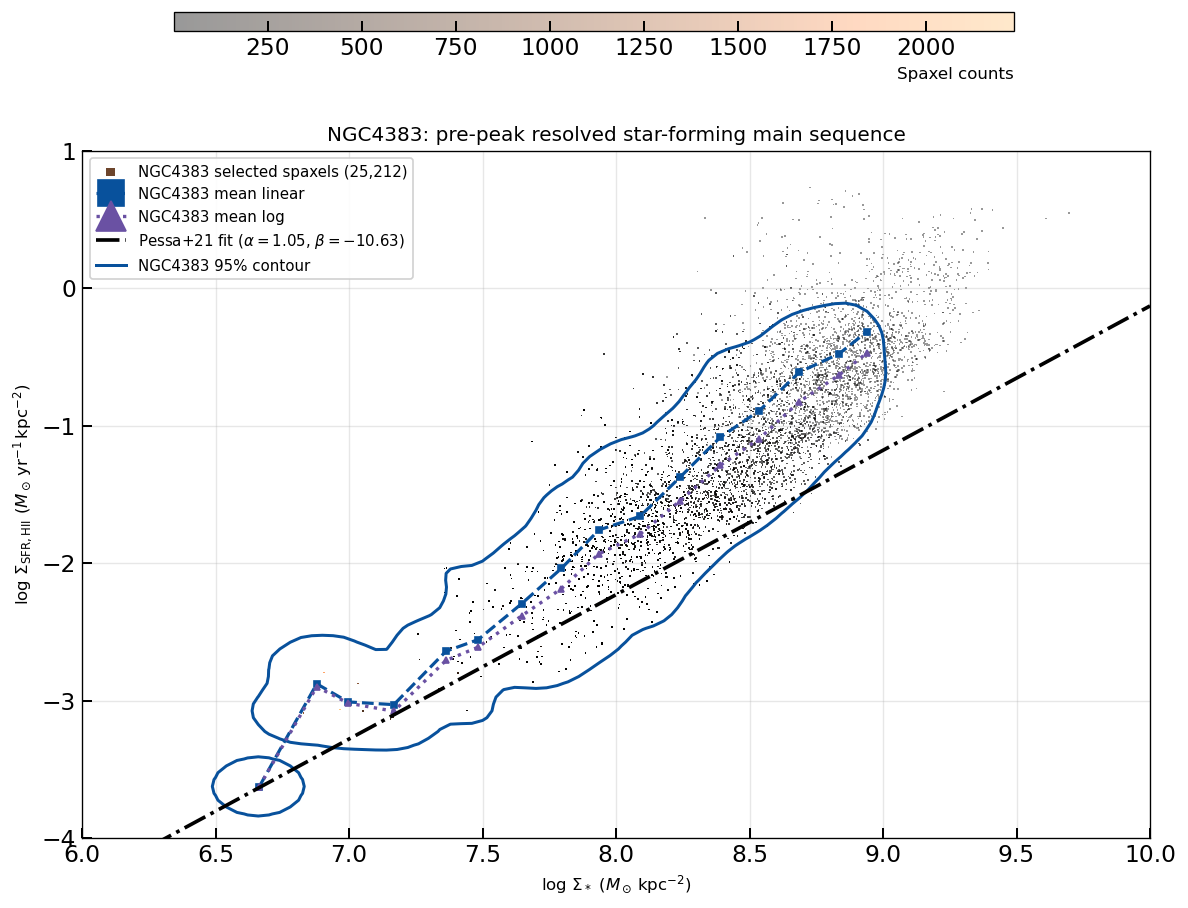

NGC4383: 25,212 selected spaxels
  Central-95% stellar-mass range: 6.664 to 8.966
  Valid trend bins: 16 of 16


In [13]:
plot_individual_prepeak_rsfms("NGC4383")


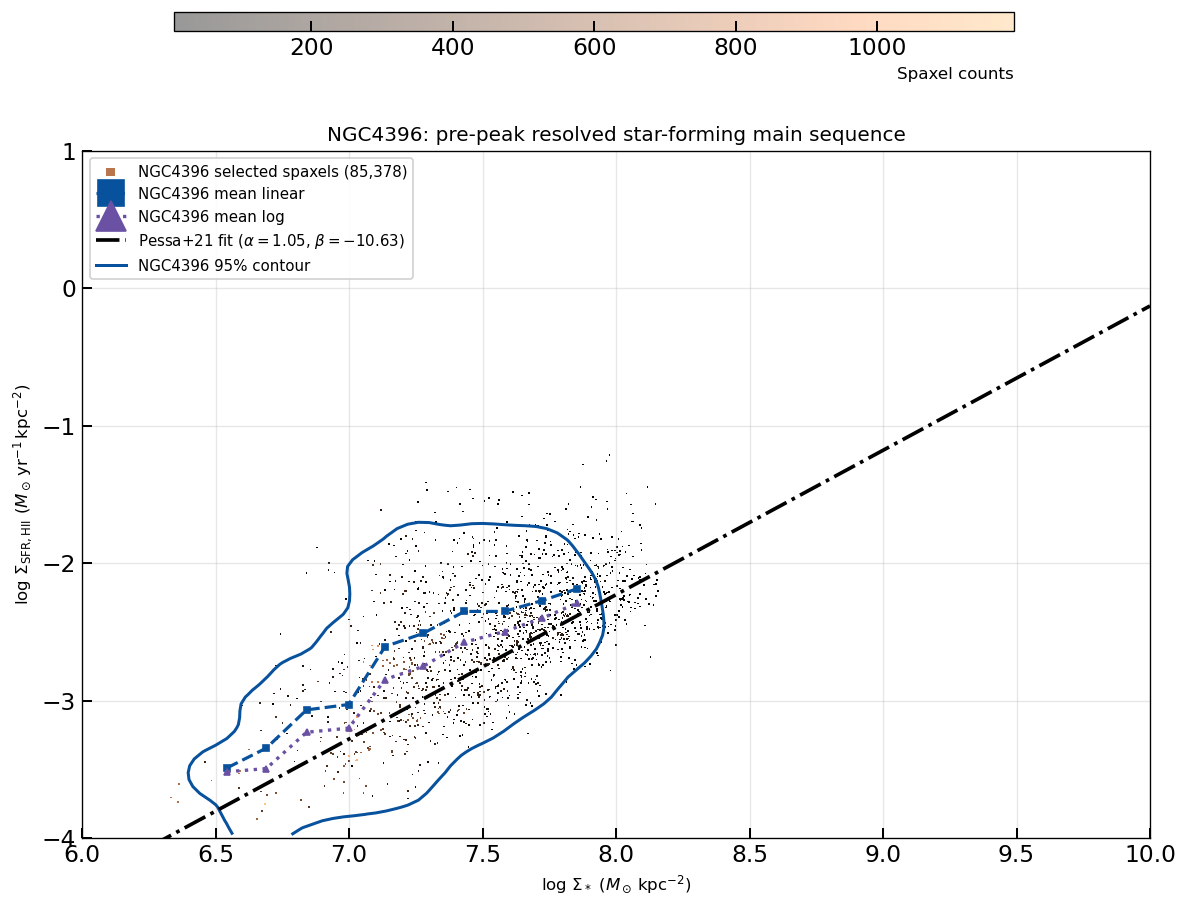

NGC4396: 85,378 selected spaxels
  Central-95% stellar-mass range: 6.461 to 7.904
  Valid trend bins: 10 of 10


In [14]:
plot_individual_prepeak_rsfms("NGC4396")


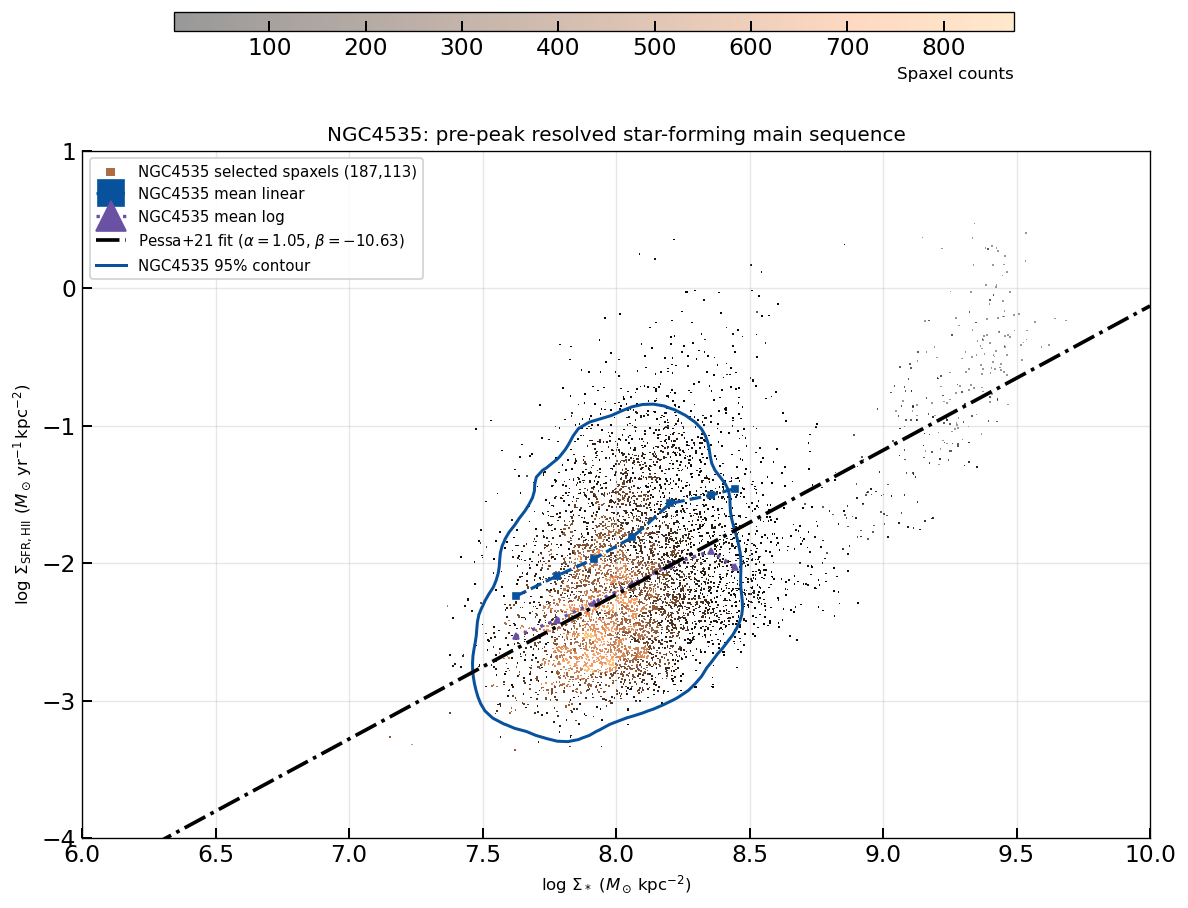

NGC4535: 187,113 selected spaxels
  Central-95% stellar-mass range: 7.541 to 8.448
  Valid trend bins: 7 of 7


In [15]:
plot_individual_prepeak_rsfms("NGC4535")


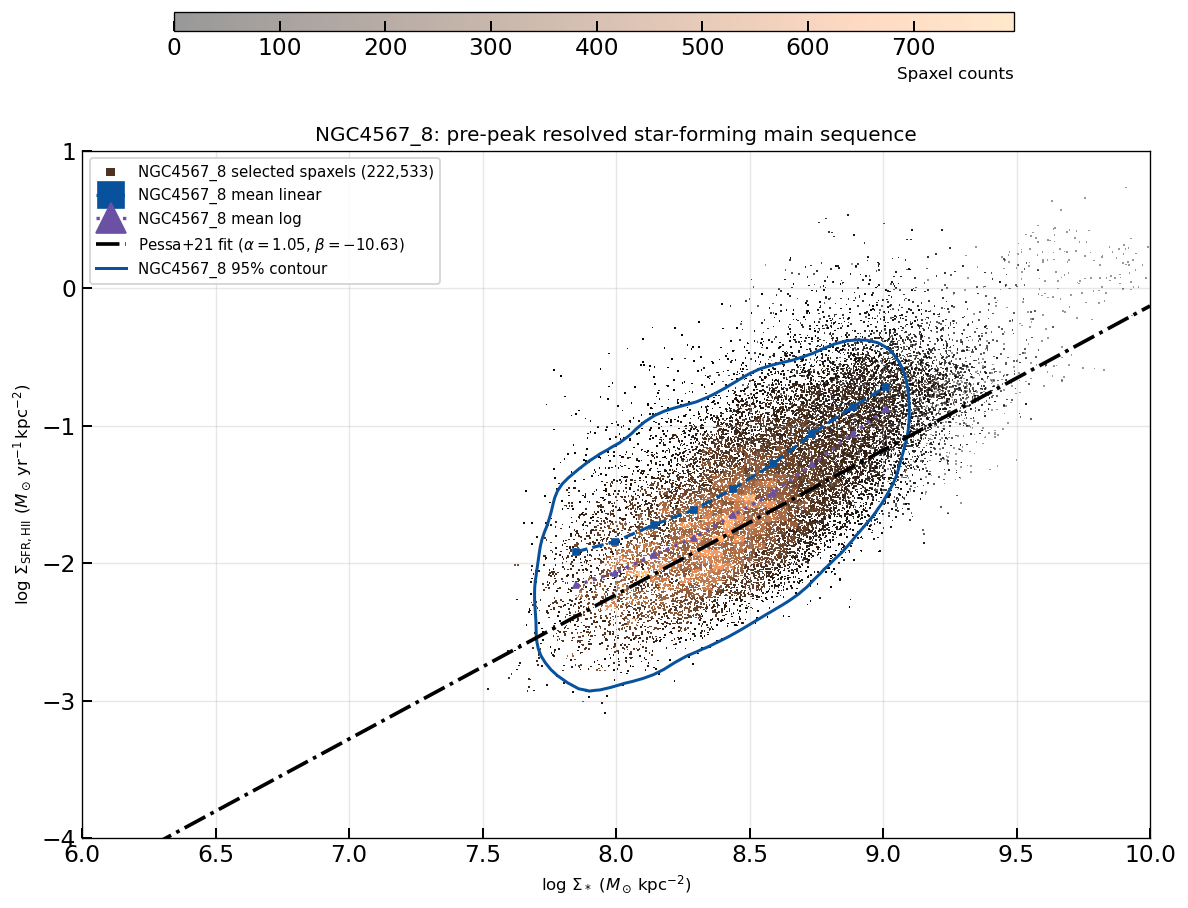

NGC4567_8: 222,533 selected spaxels
  Central-95% stellar-mass range: 7.767 to 9.058
  Valid trend bins: 9 of 9


In [16]:
plot_individual_prepeak_rsfms("NGC4567_8")


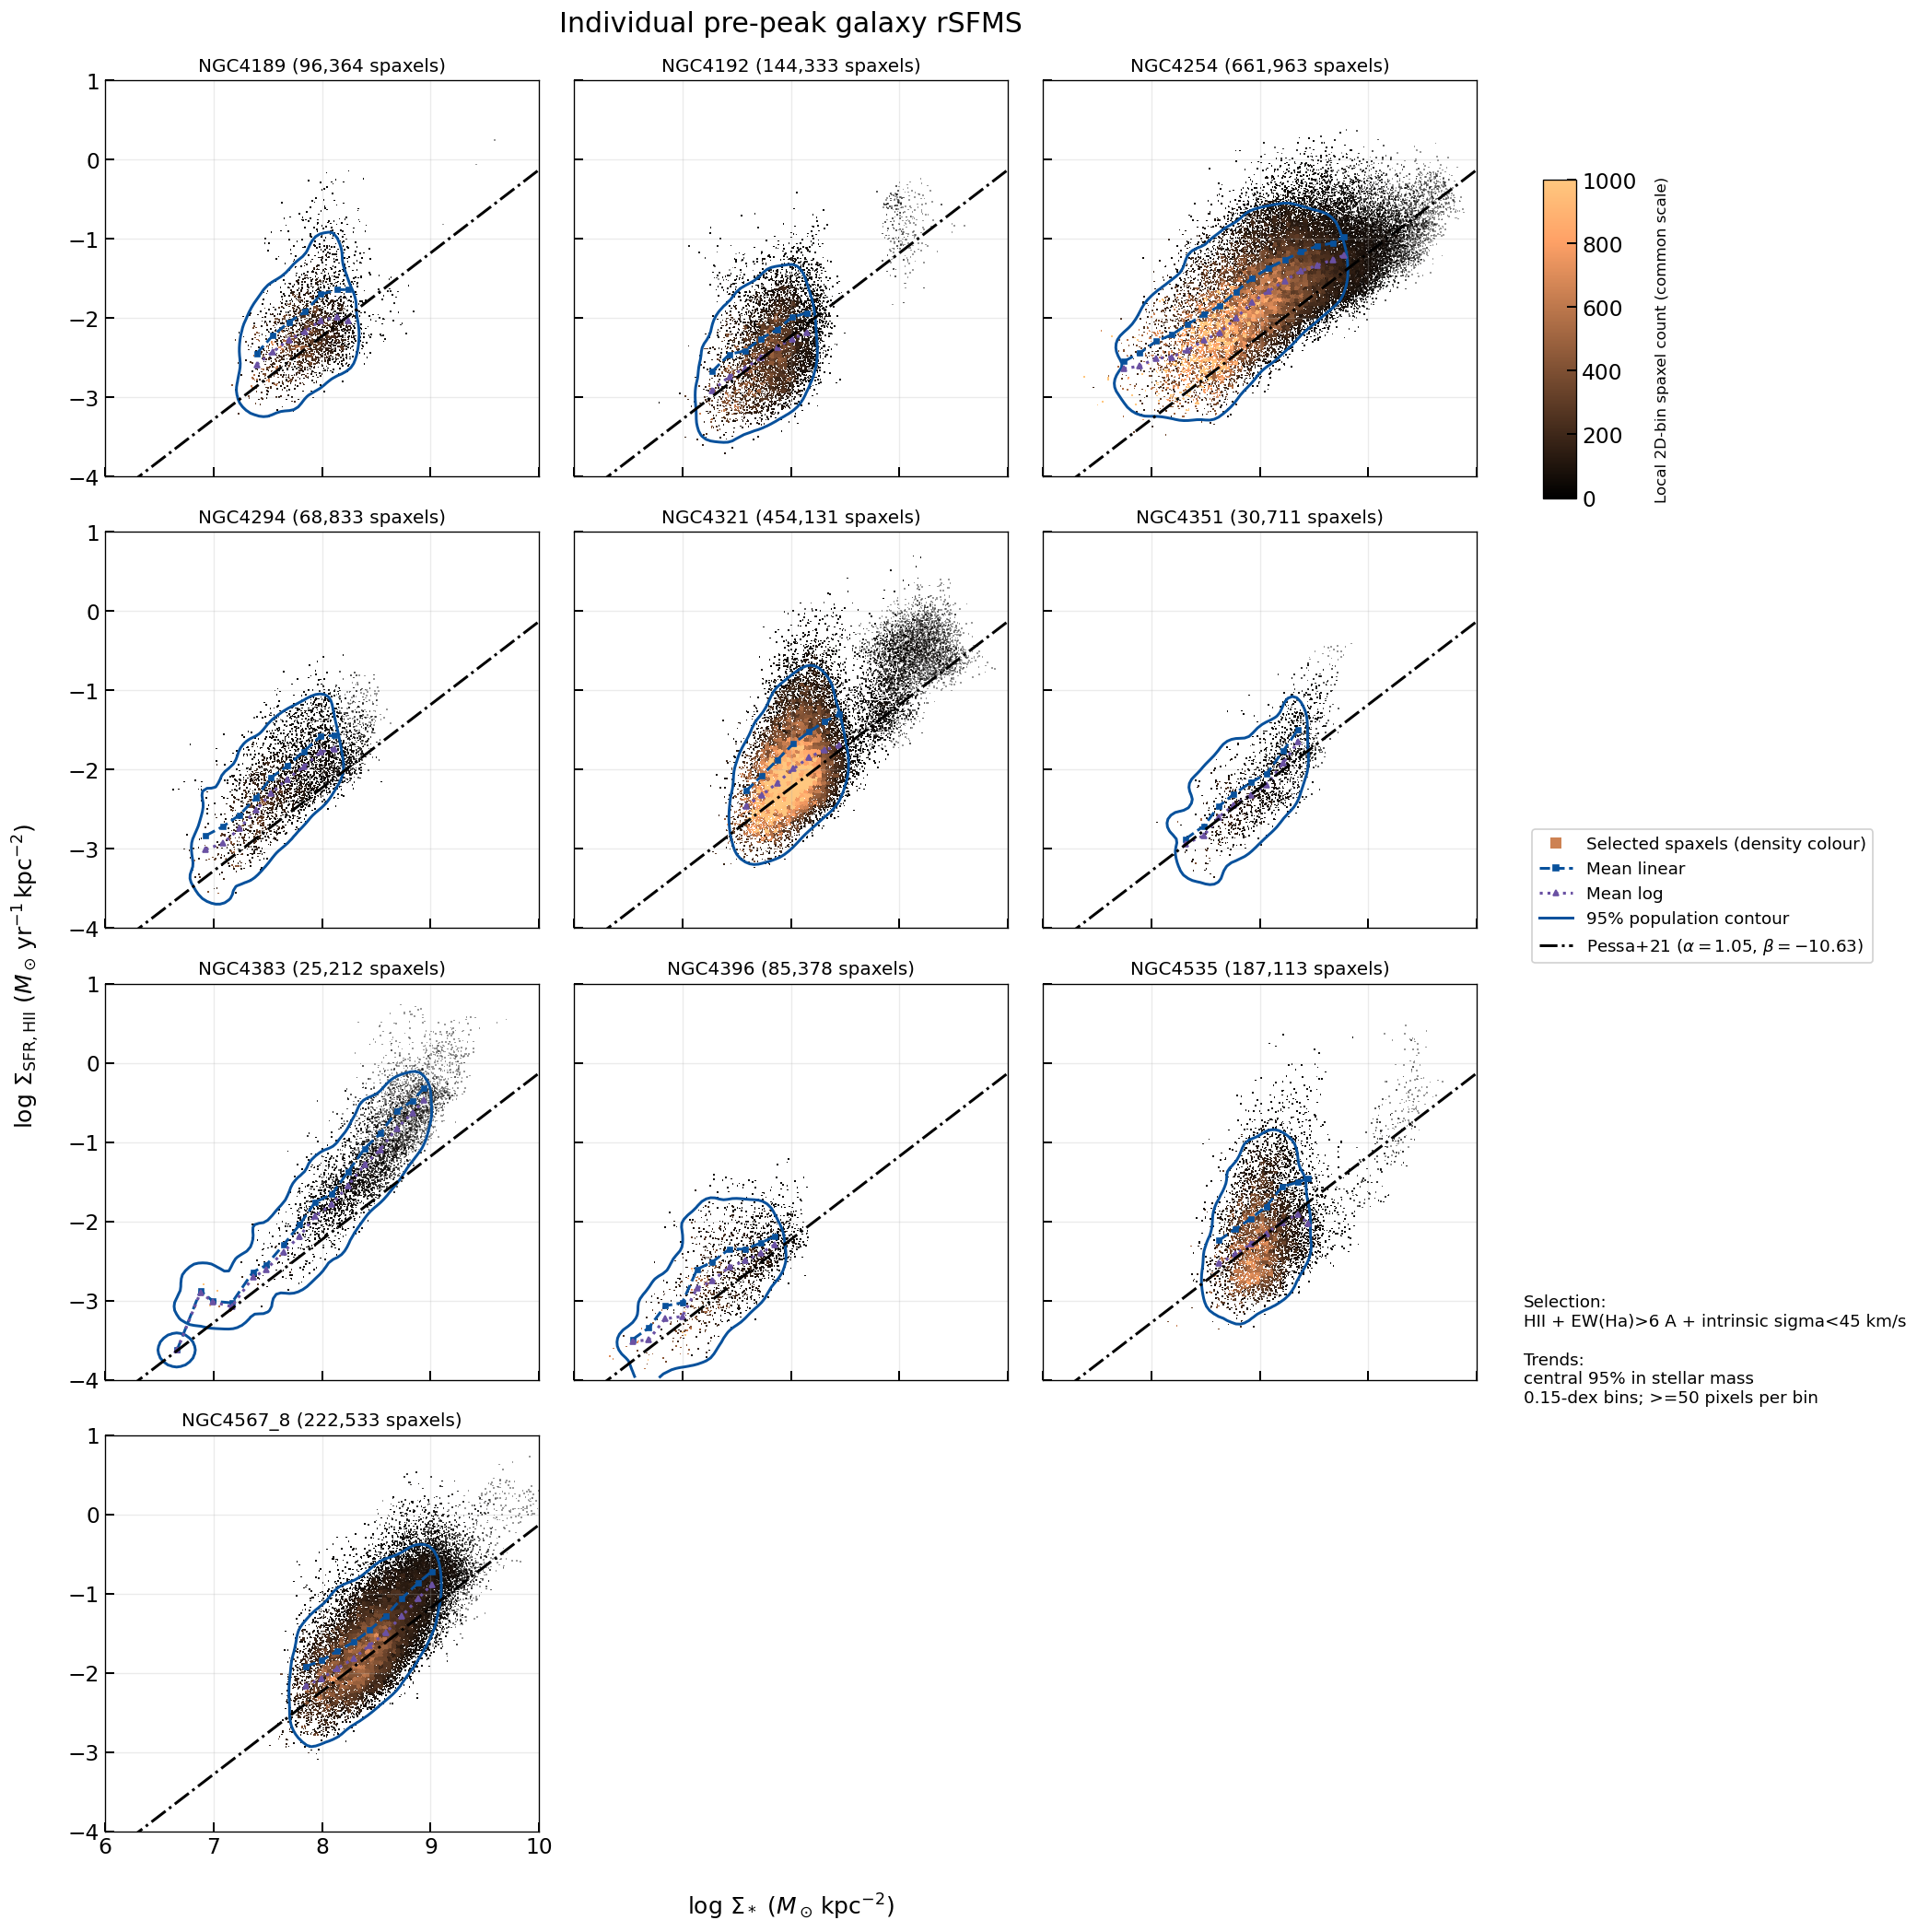

Individual pre-peak grid summary:
  NGC4189: 96,364 spaxels, central-95% mass=7.320-8.273, valid bins=7
  NGC4192: 144,333 spaxels, central-95% mass=7.200-8.192, valid bins=7
  NGC4254: 661,963 spaxels, central-95% mass=6.657-8.802, valid bins=15
  NGC4294: 68,833 spaxels, central-95% mass=6.863-8.172, valid bins=9
  NGC4321: 454,131 spaxels, central-95% mass=7.499-8.518, valid bins=7
  NGC4351: 30,711 spaxels, central-95% mass=7.243-8.434, valid bins=8
  NGC4383: 25,212 spaxels, central-95% mass=6.664-8.966, valid bins=16
  NGC4396: 85,378 spaxels, central-95% mass=6.461-7.904, valid bins=10
  NGC4535: 187,113 spaxels, central-95% mass=7.541-8.448, valid bins=7
  NGC4567_8: 222,533 spaxels, central-95% mass=7.767-9.058, valid bins=9


In [18]:
# Four-by-three summary of all currently available pre-peak galaxies.
from matplotlib.colors import Normalize

grid_galaxies = ['NGC4189', 'NGC4192', 'NGC4254', 'NGC4294', 'NGC4321', 'NGC4351', 'NGC4383', 'NGC4396', 'NGC4535', 'NGC4567_8']
grid_data = {}
GRID_DENSITY_VMAX = 1000.0

# Prepare every galaxy first so all panels can share one density normalization.
for galaxy in grid_galaxies:
    if rsfms_infall_class.get(galaxy) != RSFMS_STAGE:
        raise ValueError(f"{galaxy} is not a pre-peak galaxy")

    maps = load_selected_rsfms_maps(galaxy)
    selected = selected_rsfms_mask(*maps)
    log_sigma_m, log_sigma_sfr, _, _ = maps
    x = np.asarray(log_sigma_m[selected], dtype=float)
    y = np.asarray(log_sigma_sfr[selected], dtype=float)
    if x.size == 0:
        raise RuntimeError(f"{galaxy}: no HII+EW+sigma-selected spaxels")

    histogram, xedges, yedges = np.histogram2d(
        x,
        y,
        bins=100,
        range=[RSFMS_XRANGE, RSFMS_YRANGE],
    )
    x_index = np.clip(np.digitize(x, xedges) - 1, 0, histogram.shape[0] - 1)
    y_index = np.clip(np.digitize(y, yedges) - 1, 0, histogram.shape[1] - 1)
    density = histogram[x_index, y_index]

    (
        trend_x,
        mean_linear,
        mean_log,
        trend_counts,
        (trend_lo, trend_hi),
    ) = binned_rsfms_mean_trends(
        x,
        y,
        bin_width=RSFMS_BIN_WIDTH,
        min_pixels=RSFMS_MIN_PIXELS_PER_BIN,
    )
    grid_data[galaxy] = {
        "x": x,
        "y": y,
        "density": density,
        "trend_x": trend_x,
        "mean_linear": mean_linear,
        "mean_log": mean_log,
        "trend_counts": trend_counts,
        "trend_limits": (trend_lo, trend_hi),
    }

# Cap the shared colour scale so moderate-density structure remains visible.
grid_density_norm = Normalize(vmin=0.0, vmax=GRID_DENSITY_VMAX, clip=True)
fig, grid_axes_2d = plt.subplots(
    4,
    3,
    figsize=(17, 18),
    sharex=True,
    sharey=True,
    constrained_layout=False,
)
grid_axes = grid_axes_2d.ravel()
fig.subplots_adjust(
    left=0.07,
    right=0.80,
    bottom=0.07,
    top=0.95,
    wspace=0.08,
    hspace=0.14,
)
x_pessa_grid = np.linspace(*RSFMS_XRANGE, 200)
y_pessa_grid = pessa_alpha * x_pessa_grid + pessa_intercept

for ax, galaxy in zip(grid_axes, grid_galaxies):
    data = grid_data[galaxy]
    ax.scatter(
        data["x"],
        data["y"],
        c=data["density"],
        norm=grid_density_norm,
        s=1,
        alpha=0.4,
        marker=",",
        cmap="copper",
        edgecolors="none",
        rasterized=True,
        zorder=1,
    )
    plot_stage_95_contour(
        ax,
        data["x"],
        data["y"],
        color=RSFMS_MEAN_LINEAR_COLOR,
        zorder=STAGE_CONTOUR_ZORDER,
    )
    ax.plot(
        data["trend_x"],
        data["mean_linear"],
        color=RSFMS_MEAN_LINEAR_COLOR,
        linestyle="--",
        marker="s",
        markersize=3.0,
        linewidth=1.8,
        zorder=7.0,
    )
    ax.plot(
        data["trend_x"],
        data["mean_log"],
        color=RSFMS_MEAN_LOG_COLOR,
        linestyle=":",
        marker="^",
        markersize=3.3,
        linewidth=1.9,
        zorder=7.1,
    )
    ax.plot(
        x_pessa_grid,
        y_pessa_grid,
        color="black",
        linestyle="-.",
        linewidth=1.8,
        zorder=8.0,
    )
    ax.set(
        xlim=RSFMS_XRANGE,
        ylim=RSFMS_YRANGE,
        title=f"{galaxy} ({data['x'].size:,} spaxels)",
    )
    ax.grid(True, alpha=0.25)

# Reserve the final two positions for future pre-peak galaxies.
for ax in grid_axes[10:]:
    ax.axis("off")

legend_handles = [
    Line2D(
        [0], [0], marker="s", color="none", markerfacecolor=plt.get_cmap("copper")(0.65),
        markeredgecolor="none", markersize=7, label="Selected spaxels (density colour)",
    ),
    Line2D(
        [0], [0], color=RSFMS_MEAN_LINEAR_COLOR, linestyle="--", marker="s",
        linewidth=1.8, markersize=4, label="Mean linear",
    ),
    Line2D(
        [0], [0], color=RSFMS_MEAN_LOG_COLOR, linestyle=":", marker="^",
        linewidth=1.9, markersize=4, label="Mean log",
    ),
    Line2D(
        [0], [0], color=RSFMS_MEAN_LINEAR_COLOR, linewidth=1.8,
        label="95% population contour",
    ),
    Line2D(
        [0], [0], color="black", linestyle="-.", linewidth=1.8,
        label=r"Pessa+21 ($\alpha=1.05$, $\beta=-10.63$)",
    ),
]
fig.legend(
    handles=legend_handles,
    loc="center left",
    bbox_to_anchor=(0.825, 0.54),
    ncol=1,
    framealpha=0.9,
    fontsize=11,
)
fig.supxlabel(
    r"$\log\,\Sigma_* \ (M_\odot\,\mathrm{kpc}^{-2})$",
    x=0.435,
    y=0.025,
    fontsize=15,
)
fig.supylabel(
    r"$\log\,\Sigma_{\mathrm{SFR,HII}} \ "
    r"(M_\odot\,\mathrm{yr}^{-1}\,\mathrm{kpc}^{-2})$",
    x=0.02,
    fontsize=15,
)
fig.suptitle(
    "Individual pre-peak galaxy rSFMS",
    x=0.435,
    y=0.985,
    fontsize=18,
)

density_mappable = mpl.cm.ScalarMappable(norm=grid_density_norm, cmap="copper")
density_mappable.set_array([])
density_colorbar_axis = fig.add_axes([0.835, 0.74, 0.018, 0.16])
grid_colorbar = fig.colorbar(
    density_mappable,
    cax=density_colorbar_axis,
    orientation="vertical",
)
grid_colorbar.set_label(
    "Local 2D-bin spaxel count (common scale)",
    rotation=90,
    labelpad=12,
)
fig.text(
    0.825,
    0.34,
    "Selection:\n"
    "HII + EW(Ha)>6 A + intrinsic sigma<45 km/s\n\n"
    "Trends:\n"
    "central 95% in stellar mass\n"
    "0.15-dex bins; >=50 pixels per bin",
    ha="left",
    va="top",
    fontsize=11,
)

# plt.savefig(OUTDIR / "MAUVE_MUSE_rSFMS_pre_peak_individual_grid.png", dpi=600, bbox_inches="tight")
# plt.savefig(OUTDIR / "MAUVE_MUSE_rSFMS_pre_peak_individual_grid.pdf", bbox_inches="tight")
plt.show()

print("Individual pre-peak grid summary:")
for galaxy in grid_galaxies:
    data = grid_data[galaxy]
    trend_lo, trend_hi = data["trend_limits"]
    valid_bins = int(
        np.count_nonzero(data["trend_counts"] >= RSFMS_MIN_PIXELS_PER_BIN)
    )
    print(
        f"  {galaxy}: {data['x'].size:,} spaxels, "
        f"central-95% mass={trend_lo:.3f}-{trend_hi:.3f}, "
        f"valid bins={valid_bins}"
    )
